# Predicting Student Dropout and Academic Success

### Introduction
Student performance is the ultimate indicator for an educational institution to measure the quality of the services provided. Nowadays the studies offert is rich on multiple options and levels of expertise on the domains that form the job market. Analyzing how students perform is mandatory for institutions in order to improve and understand trends on the new genereations.

These will be the steps towards the project goals:

1. Setup and feature inspection
2. Exploratory Data Analysis
3. Data Preparation
4. Machine Learning model deployment
5. Fine-tuning
6. Evalution and Conclusions


## 1. Setup and Feature Inspection

### 1.1 Setup

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/chandima-bandara/Desktop/student-retention-analysis/data/dataset.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [142]:
print(df.shape)
print(df.columns)

(4424, 35)
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without e

The dataset has 4424 entries corresponding to student information.

It also contains 35 features, which will be treated in depth next in order to make a full picture of all the data.

### 1.2 Feature Inspection

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

### 1.3 Feature Information



| Feature                                | Description                                                                                               |
|-----------------------------------------|-----------------------------------------------------------------------------------------------------------|
| Marital status                         | The marital status of the student, encoded as a discrete numeric value.                                   |
| Application mode                       | The method of application used by the student. (Categorical)                                              |
| Application order                      | The order in which the student applied. (Numerical)                                                       |
| Course                                 | The course taken by the student. (Categorical)                                                            |
| Daytime/evening attendance             | Whether the student attends classes during the day or in the evening. (Categorical)                       |
| Previous qualification                 | The qualification obtained by the student before enrolling in higher education. (Categorical)             |
| Nationality                            | The nationality of the student, represented as a discrete numeric code.                                   |
| Mother's qualification                 | The educational qualification level of the student's mother, encoded as a discrete numeric value.          |
| Father's qualification                 | The educational qualification level of the student's father, encoded as a discrete numeric value.          |
| Mother's occupation                    | The occupation of the student's mother, represented as a discrete numeric code.                           |
| Father's occupation                    | The occupation of the student's father, represented as a discrete numeric code.                           |
| Displaced                              | Indicates whether the student is considered displaced (binary: 0 = No, 1 = Yes).                          |
| Educational special needs               | Indicates if the student has special educational needs (binary: 0 = No, 1 = Yes).                         |
| Debtor                                 | Indicates whether the student has outstanding debts (binary: 0 = No, 1 = Yes).                            |
| Tuition fees up to date                 | Indicates if the student has paid all tuition fees up to date (binary: 0 = No, 1 = Yes).                  |
| Gender                                 | The gender of the student (binary: 0 = Male, 1 = Female).                                                 |
| Scholarship holder                     | Indicates if the student is receiving a scholarship (binary: 0 = No, 1 = Yes).                            |
| Age at enrollment                      | The age of the student at the time of enrollment in higher education (discrete numeric value).             |
| International                          | Indicates if the student is an international student (binary: 0 = No, 1 = Yes).                           |
| Curricular units 1st sem (credited)     | Number of curricular units the student was credited for in the first semester (discrete numeric value).    |
| Curricular units 1st sem (enrolled)     | Number of curricular units the student enrolled in during the first semester (discrete numeric value).     |
| Curricular units 1st sem (evaluations)  | Number of curricular units evaluated in the first semester (discrete numeric value).                       |
| Curricular units 1st sem (approved)     | Number of curricular units approved in the first semester (discrete numeric value).                        |
| Curricular units 1st sem (grade)        | Average grade of the student in the first semester curricular units (continuous numeric value).            |
| Curricular units 1st sem (without evaluations) | Number of curricular units without evaluation in the first semester (discrete numeric value).         |
| Curricular units 2nd sem (credited)     | Number of curricular units credited in the second semester (discrete numeric value).                       |
| Curricular units 2nd sem (enrolled)     | Number of curricular units enrolled in the second semester (discrete numeric value).                       |
| Curricular units 2nd sem (evaluations)  | Number of curricular units evaluated in the second semester (discrete numeric value).                      |
| Curricular units 2nd sem (approved)     | Number of curricular units approved in the second semester (discrete numeric value).                       |
| Curricular units 2nd sem (grade)        | Average grade in the second semester curricular units (continuous numeric value).                          |
| Curricular units 2nd sem (without evaluations) | Number of curricular units without evaluation in the second semester (discrete numeric value).        |
| Unemployment rate                      | The unemployment rate in the country at the time of student enrollment (continuous numeric value).         |
| Inflation rate                         | The inflation rate in the country at the time of student enrollment (continuous numeric value).            |
| GDP                                    | The Gross Domestic Product of the country at the time of student enrollment (continuous numeric value).    |
| Target                                 | The outcome to predict: student dropout, academic success, or failure (categorical variable).              |

## 2. Exploratory Data Analysis

### 2.1. Univariate Analysis

In [144]:
eda = df.copy()

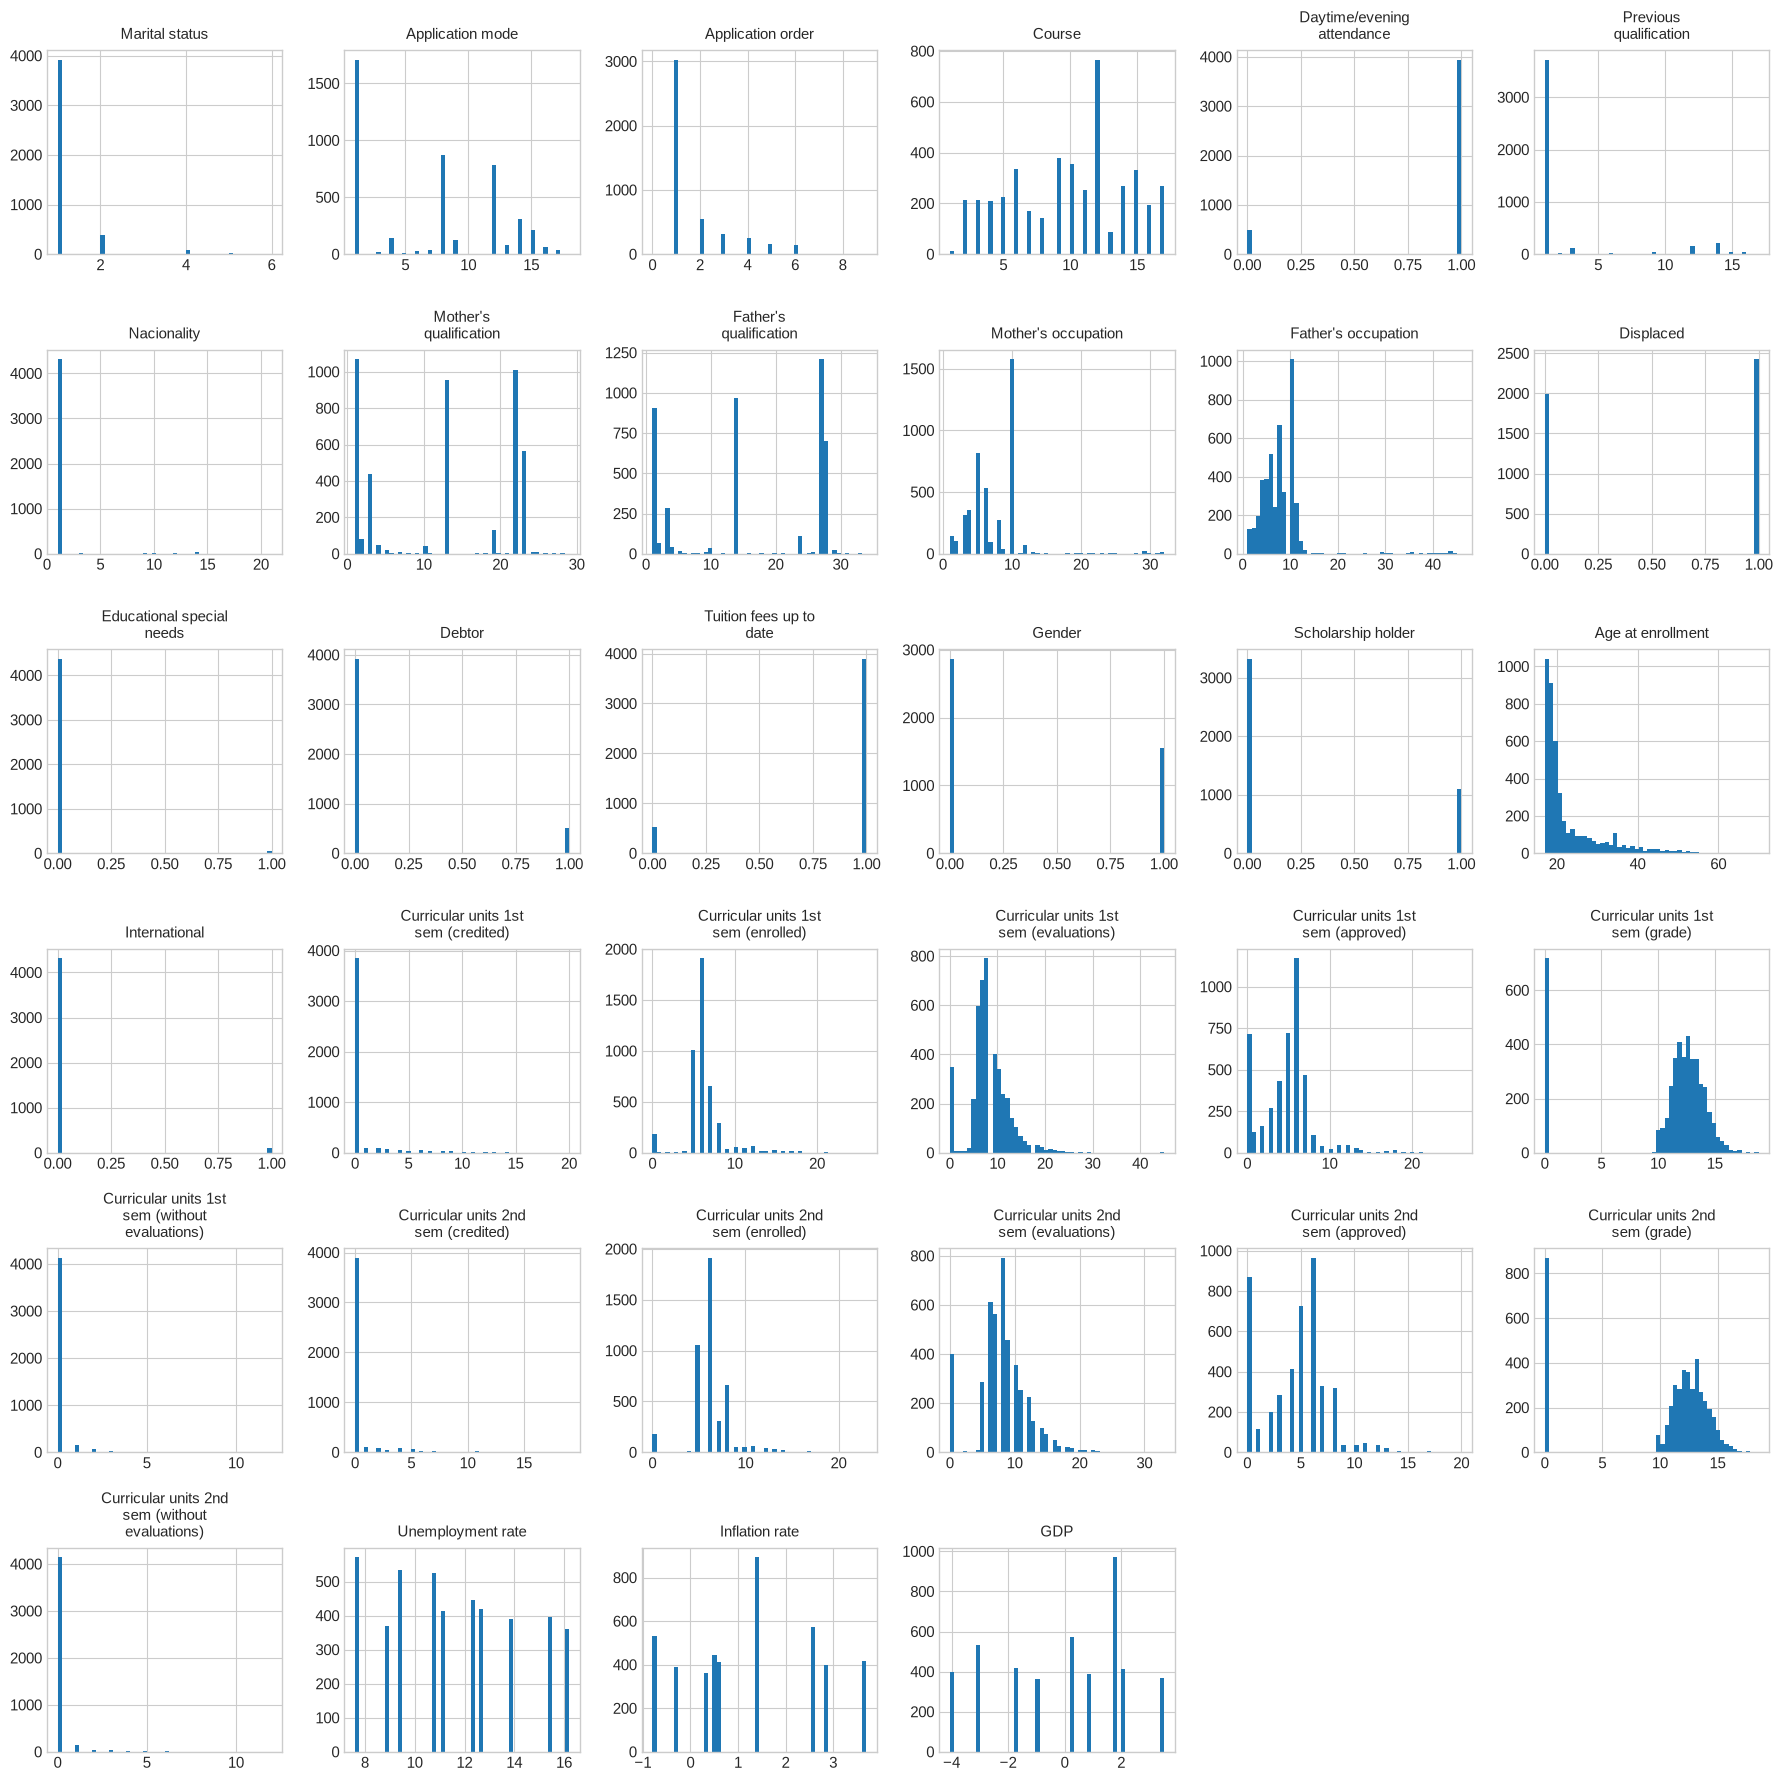

In [145]:
import textwrap

# Plot style configurations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'axes.titlesize': 16,     # Larger, readable subplot titles
    'axes.labelsize': 13,     # Axis label size
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.size': 13,           # General font size
    'legend.fontsize': 10,
    'legend.title_fontsize': 11
})

palette = {
    'Graduate': '#DD8452',  # orange
    'Dropout':  '#4C72B0',  # blue
    'Enrolled': '#55A868'   # green
}

axes = eda.hist(bins=50, figsize=(18,18))

# Flatten axes array for easy iteration (works for both 1D and 2D)
axes = axes.flatten()

# Set readable, wrapped titles
for ax in axes:
    # Wrap long titles at 20 characters
    title = ax.get_title()
    wrapped_title = "\n".join(textwrap.wrap(title, width=20))
    ax.set_title(wrapped_title, fontsize=11, pad=8)

plt.tight_layout()
plt.show()

- Most of the features are already encoded as numbers corresponding each value, that's why most distributions are simply bar charts.

- Features that follow a normal distribution are in majority left skewed and contain outliers that will need to be handled further in the project.

* `Target`: is the feature that records wether the student graduated, drop out, or is still enrolled. Thus will be the center of this project, for classification and prediction of new data falling in these categories.

    It also will be used to compare all the other variables during the analysis.

In [146]:
eda.Target.value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

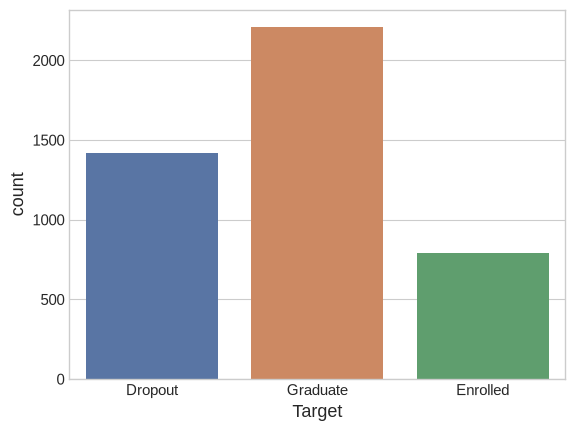

Graduate %: 0.4993218806509946
Dropout %: 0.3212025316455696
Enrolled %: 0.1794755877034358


In [147]:
sns.countplot(x='Target', hue='Target', data=eda, palette=palette, legend=False)
plt.show()

print('Graduate %:', (eda.Target == 'Graduate').sum() / len(eda))
print('Dropout %:', (eda.Target == 'Dropout').sum() / len(eda))
print('Enrolled %:', (eda.Target == 'Enrolled').sum() / len(eda))

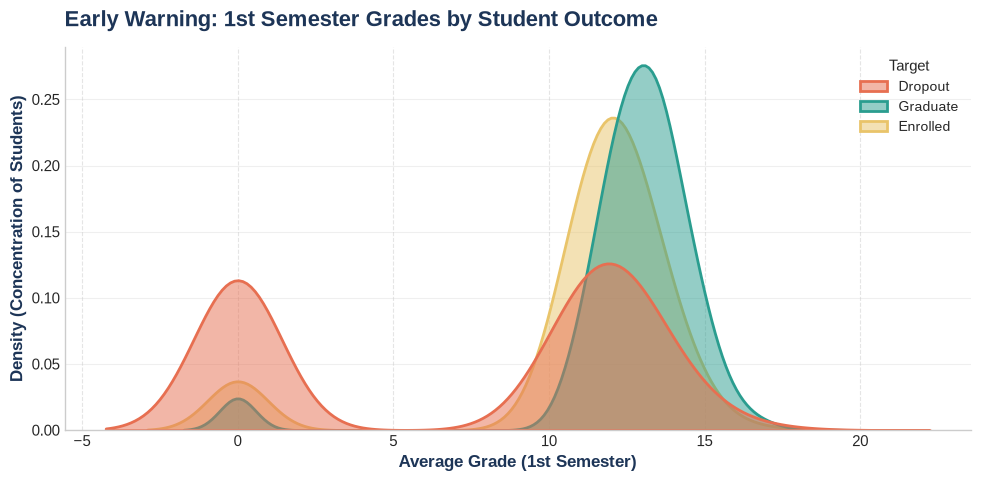

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is loaded as 'df'

fig, ax = plt.subplots(figsize=(10, 5))

# Define clean, professional colors for the Target classes
colors = {'Dropout': '#e76f51', 'Graduate': '#2a9d8f', 'Enrolled': '#e9c46a'}

# Create a smooth Density Plot (KDE) for 1st Semester Grades
sns.kdeplot(
    data=df, 
    x='Curricular units 1st sem (grade)', 
    hue='Target', 
    palette=colors,
    fill=True, 
    alpha=0.5, 
    linewidth=2,
    ax=ax,
    common_norm=False # Ensures each distribution is scaled independently for visibility
)

# Formatting the Chart to match the clean presentation style
ax.set_title('Early Warning: 1st Semester Grades by Student Outcome', 
             fontsize=16, fontweight='bold', color='#1d3557', pad=15, loc='left')
ax.set_ylabel('Density (Concentration of Students)', fontsize=12, fontweight='bold', color='#1d3557')
ax.set_xlabel('Average Grade (1st Semester)', fontsize=12, fontweight='bold', color='#1d3557')

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle grid lines for readability
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#cccccc')
ax.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Graduate** is the dominating variable over **Dropout** and **Enrolled** with a 49% of the total students

As **Dropout** and **Enrolled** are significantly less represented than **Graduate**, this leads to `Class Imbalance` in the **Target** variable.

In order to handle that, further in the project this issue will be addressed to not perform poorly.

* `Marital status`:

| ID | Marital Status         |
|----|------------------------|
| 1  | Single                 |
| 2  | Married                |
| 3  | Widower                |
| 4  | Divorced               |
| 5  | Common-law marriage    |
| 6  | Legally separated      |

In [149]:
mat_labels = ['Single', 'Married', 'Widower', 'Divorced', 'Common-law marriage', 'Legally separated']
eda['Marital_labels'] = eda['Marital status'].map(lambda x: mat_labels[x - 1])


eda['Marital_labels'].value_counts()

Marital_labels
Single                 3919
Married                 379
Divorced                 91
Common-law marriage      25
Legally separated         6
Widower                   4
Name: count, dtype: int64

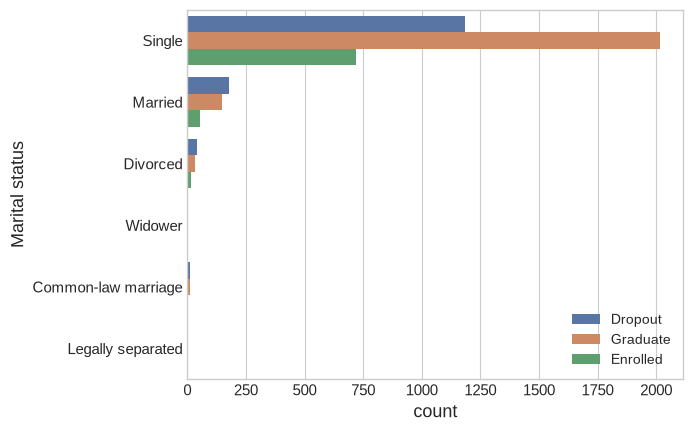

Single percentage: 0.8858499095840868
Married percentage: 0.08566907775768536
Divorced percentage: 0.020569620253164556


In [150]:
mat_labels = ['Single', 'Married', 'Widower', 'Divorced', 'Common-law marriage', 'Legally separated']
eda['Marital_labels'] = eda['Marital status'].map(lambda x: mat_labels[x - 1])

sns.countplot(y='Marital_labels', hue='Target', data=eda, palette=palette)
plt.ylabel('Marital status')
plt.legend(loc=4)
plt.show()

print('Single percentage:', (eda['Marital status'] == 1).sum() / len(eda))
print('Married percentage:', (eda['Marital status'] == 2).sum() / len(eda))
print('Divorced percentage:', (eda['Marital status'] == 4).sum() / len(eda))

The status of the students from the dataset is 88.5% **single**. It is interesting to note that **dropout** prevalence is higher in the other categories.

* `Application mode`:

| ID | Aplication Mode                                         |
|----|--------------------------------------------------------|
| 1  | 1st phase—general contingent                           |
| 2  | Ordinance No. 612/93                                   |
| 3  | 1st phase—special contingent (Azores Island)           |
| 4  | Holders of other higher courses                        |
| 5  | Ordinance No. 854-B/99                                |
| 6  | International student (bachelor)                       |
| 7  | 1st phase—special contingent (Madeira Island)          |
| 8  | 2nd phase—general contingent                           |
| 9  | 3rd phase—general contingent                           |
| 10 | Ordinance No. 533-A/99, item b2) (Different Plan)      |
| 11 | Ordinance No. 533-A/99, item b3 (Other Institution)    |
| 12 | Over 23 years old                                      |
| 13 | Transfer                                               |
| 14 | Change in course                                       |
| 15 | Technological specialization diploma holders           |
| 16 | Change in institution/course                           |
| 17 | Short cycle diploma holders                            |
| 18 | Change in institution/course (International)           |

In [151]:
application_mode_labels = [
    "1st phase—general contingent",
    "Ordinance No. 612/93",
    "1st phase—special contingent (Azores Island)",
    "Holders of other higher courses",
    "Ordinance No. 854-B/99",
    "International student (bachelor)",
    "1st phase—special contingent (Madeira Island)",
    "2nd phase—general contingent",
    "3rd phase—general contingent",
    "Ordinance No. 533-A/99, item b2) (Different Plan)",
    "Ordinance No. 533-A/99, item b3 (Other Institution)",
    "Over 23 years old",
    "Transfer",
    "Change in course",
    "Technological specialization diploma holders",
    "Change in institution/course",
    "Short cycle diploma holders",
    "Change in institution/course (International)"
]
eda['app_mode_labels'] = eda['Application mode'].map(lambda x: application_mode_labels[x - 1])

eda['app_mode_labels'].value_counts()

app_mode_labels
1st phase—general contingent                           1708
2nd phase—general contingent                            872
Over 23 years old                                       785
Change in course                                        312
Technological specialization diploma holders            213
Holders of other higher courses                         139
3rd phase—general contingent                            124
Transfer                                                 77
Change in institution/course                             59
1st phase—special contingent (Madeira Island)            38
Short cycle diploma holders                              35
International student (bachelor)                         30
1st phase—special contingent (Azores Island)             16
Ordinance No. 854-B/99                                   10
Ordinance No. 612/93                                      3
Change in institution/course (International)              1
Ordinance No. 533-A/99, 

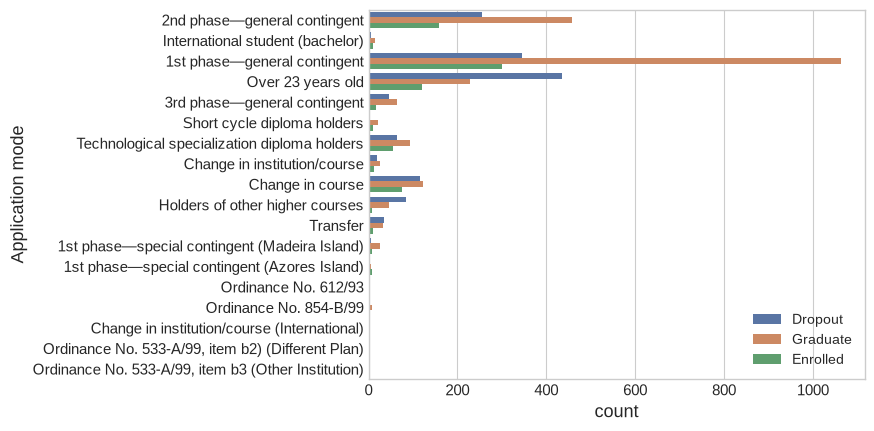

In [152]:

sns.countplot(y='app_mode_labels', hue='Target', data=eda, palette=palette)
plt.ylabel('Application mode')
plt.legend(loc=4)
plt.show()

Most of the students applicated trough general contingent. An interesting metric too is that most of the applicators over 23 year old are labelled as dropouts.

* `Application order`:

In [153]:
eda['Application order'].value_counts()

Application order
1    3026
2     547
3     309
4     249
5     154
6     137
9       1
0       1
Name: count, dtype: int64

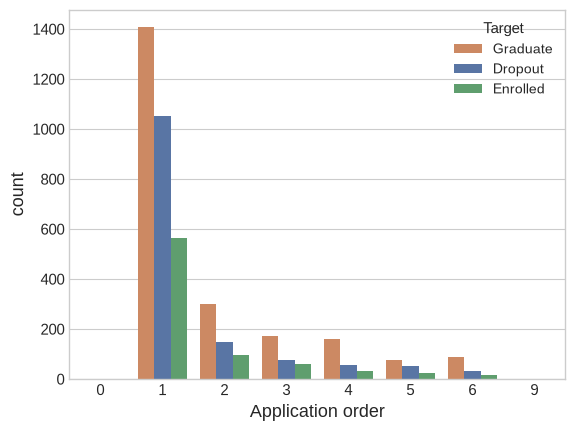

0.683996383363472


In [154]:
sns.countplot(x='Application order', hue='Target', data=eda, palette=palette)
plt.show()
print((eda['Application order'] == 1).sum() / len(eda))

Nothing interesting to note here, most students applicated first (68.4%) to the Polytechnic Institute of Portalegre. There's also a 0  that could mean an error on registering the information.

* `Course` :

| ID | Course                           |
|----|--------------------------------------|
| 1  | Biofuel Production Technologies      |
| 2  | Animation and Multimedia Design      |
| 3  | Social Service (evening attendance)  |
| 4  | Agronomy                            |
| 5  | Communication Design                 |
| 6  | Veterinary Nursing                   |
| 7  | Informatics Engineering              |
| 8  | Equiniculture                        |
| 9  | Management                           |
| 10 | Social Service                       |
| 11 | Tourism                              |
| 12 | Nursing                              |
| 13 | Oral Hygiene                         |
| 14 | Advertising and Marketing Management |
| 15 | Journalism and Communication         |
| 16 | Basic Education                      |
| 17 | Management (evening attendance)      |

In [155]:
course_labels = [
    "Biofuel Production Technologies",
    "Animation and Multimedia Design",
    "Social Service (evening attendance)",
    "Agronomy",
    "Communication Design",
    "Veterinary Nursing",
    "Informatics Engineering",
    "Equiniculture",
    "Management",
    "Social Service",
    "Tourism",
    "Nursing",
    "Oral Hygiene",
    "Advertising and Marketing Management",
    "Journalism and Communication",
    "Basic Education",
    "Management (evening attendance)"
]


eda['course_labels'] = eda['Course'].map(lambda x: course_labels[x - 1])
eda['course_labels'].value_counts()

course_labels
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Management (evening attendance)         268
Advertising and Marketing Management    268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Service (evening attendance)     215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equiniculture                           141
Oral Hygiene                             86
Biofuel Production Technologies          12
Name: count, dtype: int64

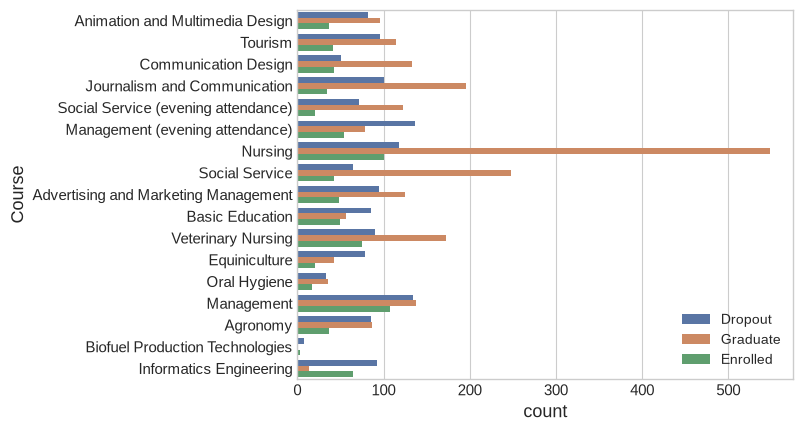

In [156]:

sns.countplot(y='course_labels', hue='Target', data=eda, palette=palette)
plt.ylabel('Course')
plt.legend(loc=4)
plt.show()

**Nursing** is by far the course with more graduates, then **social service**. **Management** despite being the second most popular course has an almost 50/50 ratio of graduates-dropouts. **Equiniculture**, **Informatics engineering** and **managment evening time** are the courses with most prevalence in dropouts.

* `Daytime/evening attendance`:

In [157]:
eda['Daytime/evening attendance'].value_counts()

Daytime/evening attendance
1    3941
0     483
Name: count, dtype: int64

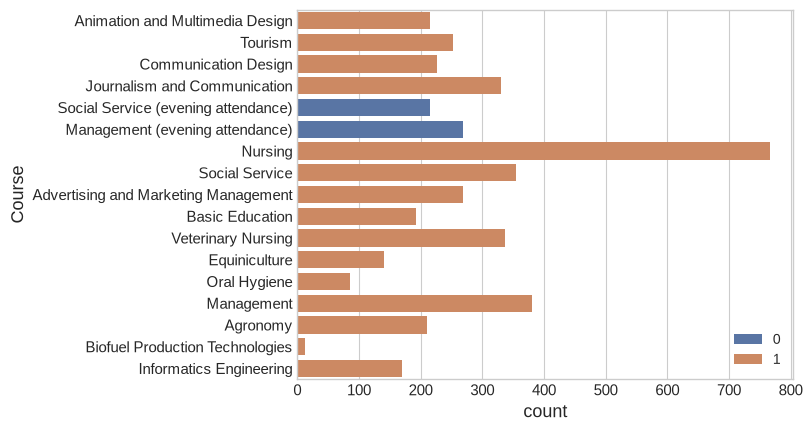

In [158]:
sns.countplot(y='course_labels', hue='Daytime/evening attendance', data=eda, palette='deep')
plt.ylabel('Course')
plt.legend(loc=4)
plt.show()

Only **social services** and **management** have an evening time option.

* `Previous qualification`:

| ID | Previous Qualification                                                     |
|----|---------------------------------------------------------------------------|
| 1  | Secondary education                                                       |
| 2  | Higher education—bachelor’s degree                                        |
| 3  | Higher education—degree                                                   |
| 4  | Higher education—master’s degree                                          |
| 5  | Higher education—doctorate                                                |
| 6  | Frequency of higher education                                             |
| 7  | 12th year of schooling—not completed                                      |
| 8  | 11th year of schooling—not completed                                      |
| 9  | Other—11th year of schooling                                              |
| 10 | 10th year of schooling                                                    |
| 11 | 10th year of schooling—not completed                                      |
| 12 | Basic education 3rd cycle (9th/10th/11th year) or equivalent              |
| 13 | Basic education 2nd cycle (6th/7th/8th year) or equivalent                |
| 14 | Technological specialization course                                       |
| 15 | Higher education—degree (1st cycle)                                       |
| 16 | Professional higher technical course                                      |
| 17 | Higher education—master’s degree (2nd cycle)                              |

In [159]:
previous_qual_labels = [
    "Secondary education",
    "Higher education—bachelor’s degree",
    "Higher education—degree",
    "Higher education—master’s degree",
    "Higher education—doctorate",
    "Frequency of higher education",
    "12th year of schooling—not completed",
    "11th year of schooling—not completed",
    "Other—11th year of schooling",
    "10th year of schooling",
    "10th year of schooling—not completed",
    "Basic education 3rd cycle (9th/10th/11th year) or equivalent",
    "Basic education 2nd cycle (6th/7th/8th year) or equivalent",
    "Technological specialization course",
    "Higher education—degree (1st cycle)",
    "Professional higher technical course",
    "Higher education—master’s degree (2nd cycle)"
]

eda['qual_labels'] = eda['Previous qualification'].map(lambda x: previous_qual_labels[x - 1])
eda['qual_labels'].value_counts()

qual_labels
Secondary education                                             3717
Technological specialization course                              219
Basic education 3rd cycle (9th/10th/11th year) or equivalent     162
Higher education—degree                                          126
Other—11th year of schooling                                      45
Higher education—degree (1st cycle)                               40
Professional higher technical course                              36
Higher education—bachelor’s degree                                23
Frequency of higher education                                     16
12th year of schooling—not completed                              11
Higher education—master’s degree                                   8
Basic education 2nd cycle (6th/7th/8th year) or equivalent         7
Higher education—master’s degree (2nd cycle)                       6
11th year of schooling—not completed                               4
10th year of schooling

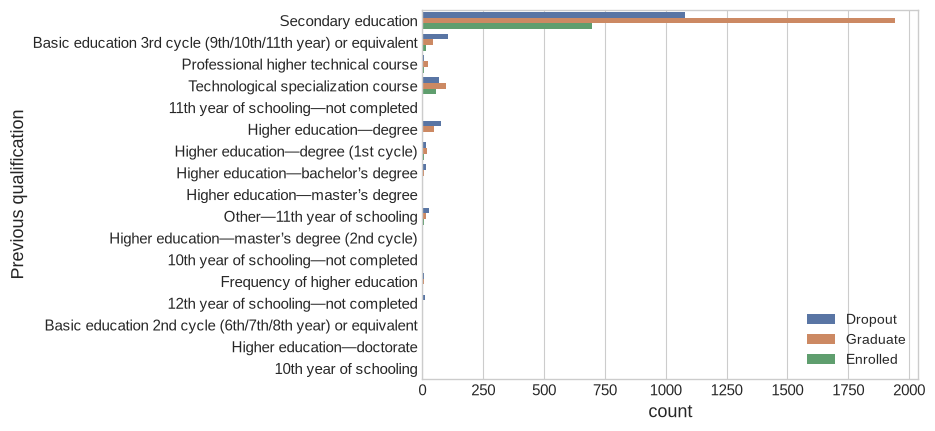

In [160]:
sns.countplot(y='qual_labels', hue='Target', data=eda, palette=palette)
plt.ylabel('Previous qualification')
plt.legend(loc=4)
plt.show()

Most of the students come from **Secondary education**, students that come from **Basic education 3rd cycle** have a bigger dropout rate than graduation rate.

* `Nationality`:

| ID | Language                |
|----|-------------------------|
| 1  | Portuguese              |
| 2  | German                  |
| 3  | Spanish                 |
| 4  | Italian                 |
| 5  | Dutch                   |
| 6  | English                 |
| 7  | Lithuanian              |
| 8  | Angolan                 |
| 9  | Cape Verdean            |
| 10 | Guinean                 |
| 11 | Mozambican              |
| 12 | Santomean               |
| 13 | Turkish                 |
| 14 | Brazilian               |
| 15 | Romanian                |
| 16 | Moldova (Republic of)   |
| 17 | Mexican                 |
| 18 | Ukrainian               |
| 19 | Russian                 |
| 20 | Cuban                   |
| 21 | Colombian               |

The `Nationality` feature is wrongly spelled (Nacionality instead of Nationality), that's why it is corrected below.

In [161]:
df = df.rename(columns={'Nacionality' : 'Nationality'})
eda = eda.rename(columns={'Nacionality' : 'Nationality'})

In [162]:
language_labels = [
    "Portuguese",
    "German",
    "Spanish",
    "Italian",
    "Dutch",
    "English",
    "Lithuanian",
    "Angolan",
    "Cape Verdean",
    "Guinean",
    "Mozambican",
    "Santomean",
    "Turkish",
    "Brazilian",
    "Romanian",
    "Moldova (Republic of)",
    "Mexican",
    "Ukrainian",
    "Russian",
    "Cuban",
    "Colombian"
]

eda['nat_labels'] = eda['Nationality'].map(lambda x: language_labels[x - 1])
eda['nat_labels'].value_counts()

nat_labels
Portuguese               4314
Brazilian                  38
Santomean                  14
Spanish                    13
Cape Verdean               13
Guinean                     5
Ukrainian                   3
Italian                     3
Moldova (Republic of)       3
Romanian                    2
Mozambican                  2
Angolan                     2
Mexican                     2
German                      2
Russian                     2
Dutch                       1
Turkish                     1
Colombian                   1
Cuban                       1
English                     1
Lithuanian                  1
Name: count, dtype: int64

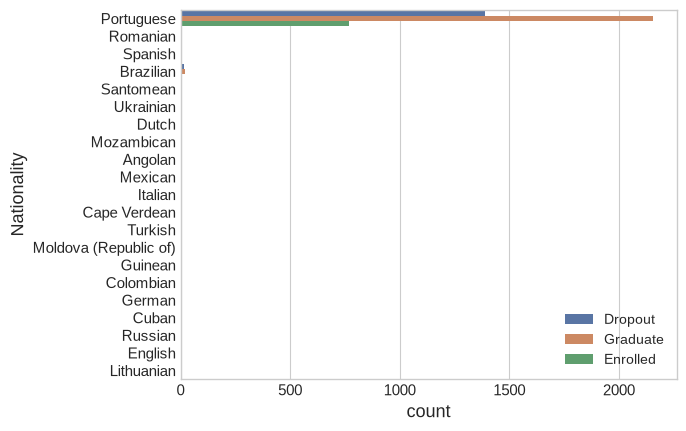

In [163]:
sns.countplot(y='nat_labels', hue='Target', data=eda, palette=palette)
plt.ylabel('Nationality')
plt.legend(loc=4)
plt.show()

The mayority of the students from the dataset are **Portuguese**.

* `Mother's qualification`

| ID | Parent Qualification                                                        |
|----|----------------------------------------------------------------------------|
| 1  | Secondary Education—12th Year of Schooling or Equivalent                   |
| 2  | Higher Education—bachelor’s degree                                         |
| 3  | Higher Education—degree                                                    |
| 4  | Higher Education—master’s degree                                           |
| 5  | Higher Education—doctorate                                                 |
| 6  | Frequency of Higher Education                                              |
| 7  | 12th Year of Schooling—not completed                                       |
| 8  | 11th Year of Schooling—not completed                                       |
| 9  | 7th Year (Old)                                                            |
| 10 | Other—11th Year of Schooling                                               |
| 11 | 2nd year complementary high school course                                  |
| 12 | 10th Year of Schooling                                                     |
| 13 | General commerce course                                                    |
| 14 | Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent               |
| 15 | Complementary High School Course                                           |
| 16 | Technical-professional course                                              |
| 17 | Complementary High School Course—not concluded                             |
| 18 | 7th year of schooling                                                      |
| 19 | 2nd cycle of the general high school course                                |
| 20 | 9th Year of Schooling—not completed                                        |
| 21 | 8th year of schooling                                                      |
| 22 | General Course of Administration and Commerce                              |
| 23 | Supplementary Accounting and Administration                                |
| 24 | Unknown                                                                   |
| 25 | Cannot read or write                                                       |
| 26 | Can read without having a 4th year of schooling                            |
| 27 | Basic education 1st cycle (4th/5th year) or equivalent                     |
| 28 | Basic Education 2nd Cycle (6th/7th/8th Year) or equivalent                 |
| 29 | Technological specialization course                                        |
| 30 | Higher education—degree (1st cycle)                                        |
| 31 | Specialized higher studies course                                          |
| 32 | Professional higher technical course                                       |
| 33 | Higher Education—master’s degree (2nd cycle)                               |
| 34 | Higher Education—doctorate (3rd cycle)                                     |

In [164]:
parent_qual_labels = [
    "Secondary Education—12th Year of Schooling or Equivalent",
    "Higher Education—bachelor’s degree",
    "Higher Education—degree",
    "Higher Education—master’s degree",
    "Higher Education—doctorate",
    "Frequency of Higher Education",
    "12th Year of Schooling—not completed",
    "11th Year of Schooling—not completed",
    "7th Year (Old)",
    "Other—11th Year of Schooling",
    "2nd year complementary high school course",
    "10th Year of Schooling",
    "General commerce course",
    "Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent",
    "Complementary High School Course",
    "Technical-professional course",
    "Complementary High School Course—not concluded",
    "7th year of schooling",
    "2nd cycle of the general high school course",
    "9th Year of Schooling—not completed",
    "8th year of schooling",
    "General Course of Administration and Commerce",
    "Supplementary Accounting and Administration",
    "Unknown",
    "Cannot read or write",
    "Can read without having a 4th year of schooling",
    "Basic education 1st cycle (4th/5th year) or equivalent",
    "Basic Education 2nd Cycle (6th/7th/8th Year) or equivalent",
    "Technological specialization course",
    "Higher education—degree (1st cycle)",
    "Specialized higher studies course",
    "Professional higher technical course",
    "Higher Education—master’s degree (2nd cycle)",
    "Higher Education—doctorate (3rd cycle)"
]

eda['m_labels'] = eda['Mother\'s qualification'].map(lambda x: parent_qual_labels[x - 1])
eda['m_labels'].value_counts()


m_labels
Secondary Education—12th Year of Schooling or Equivalent        1069
General Course of Administration and Commerce                   1009
General commerce course                                          953
Supplementary Accounting and Administration                      562
Higher Education—degree                                          438
2nd cycle of the general high school course                      130
Higher Education—bachelor’s degree                                83
Higher Education—master’s degree                                  49
Other—11th Year of Schooling                                      42
Higher Education—doctorate                                        21
Cannot read or write                                               9
12th Year of Schooling—not completed                               8
Unknown                                                            8
Can read without having a 4th year of schooling                    6
Basic education 1st cycle

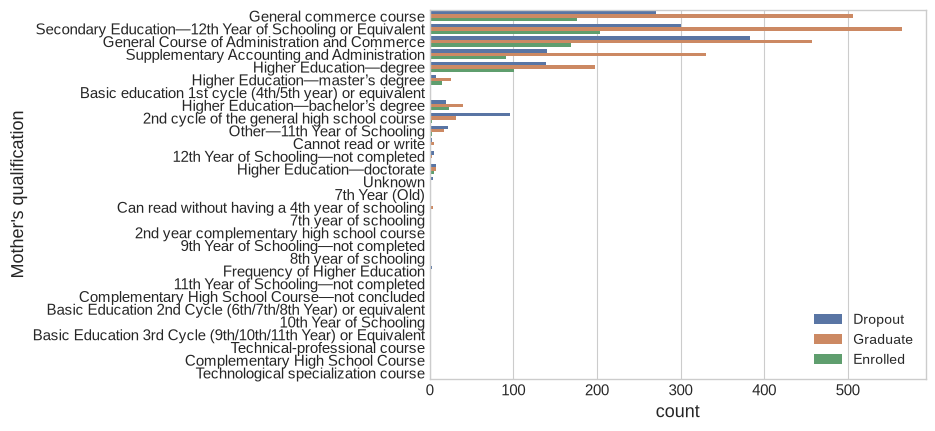

In [165]:
sns.countplot(y='m_labels', hue='Target', data=eda, palette=palette)
plt.ylabel('Mother\'s qualification')
plt.legend(loc=4)
plt.show()

As there's an elevated quantity of labels, the representation shows labels with **+10 entries**:

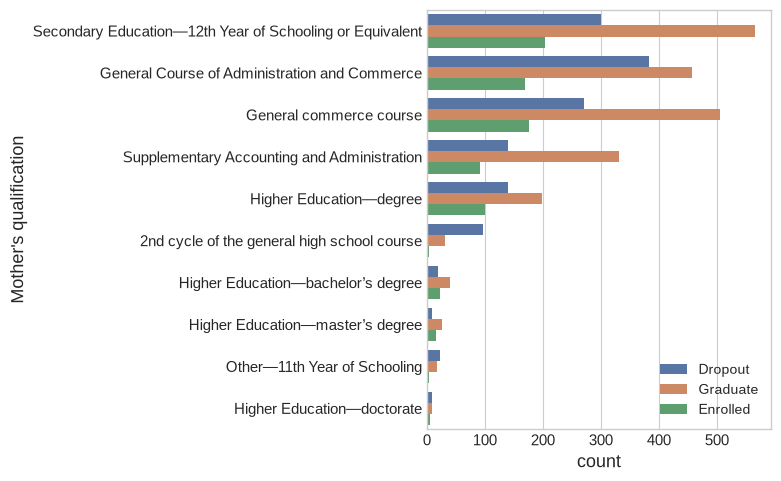

In [166]:
label_counts = eda['m_labels'].value_counts()
labels_to_keep = label_counts[label_counts >= 10].index
filtered_eda = eda[eda['m_labels'].isin(labels_to_keep)]

plt.figure(figsize=(8, 5))
sns.countplot(
    y='m_labels',
    hue='Target',
    data=filtered_eda,
    palette=palette,
    order=labels_to_keep
)
plt.ylabel("Mother's qualification")
plt.legend(loc=4)
plt.tight_layout()
plt.show()

The majority of female progenitors have education in Secondary Education—12th Year of Schooling or Equivalent, General Course of Administration and Commerce and General commerce course.


* `Father's qualification`

Labels are the same as Mother's qualification.

In [167]:
eda['f_labels'] = eda['Father\'s qualification'].map(lambda x: parent_qual_labels[x - 1])
eda['f_labels'].value_counts()

f_labels
Basic education 1st cycle (4th/5th year) or equivalent          1209
Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent     968
Secondary Education—12th Year of Schooling or Equivalent         904
Basic Education 2nd Cycle (6th/7th/8th Year) or equivalent       702
Higher Education—degree                                          282
Unknown                                                          112
Higher Education—bachelor’s degree                                68
Higher Education—master’s degree                                  39
Other—11th Year of Schooling                                      38
Technological specialization course                               20
Higher Education—doctorate                                        18
7th Year (Old)                                                    10
Can read without having a 4th year of schooling                    8
12th Year of Schooling—not completed                               5
Higher education—degree (

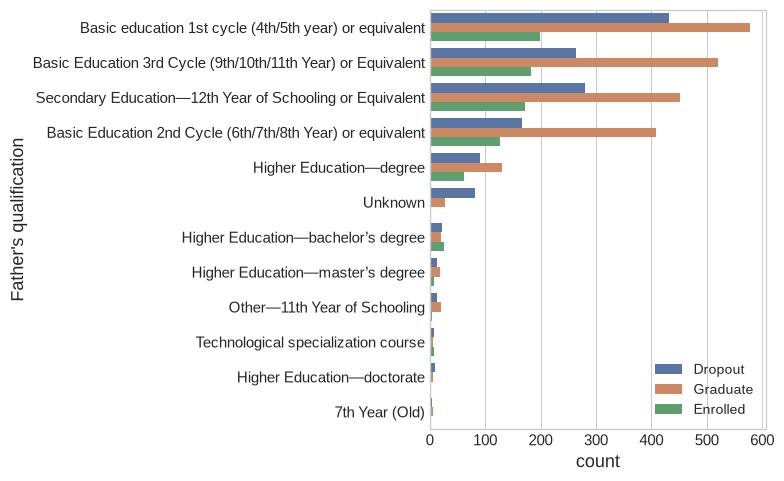

In [168]:
label_counts = eda['f_labels'].value_counts()
labels_to_keep = label_counts[label_counts >= 10].index
filtered_eda = eda[eda['f_labels'].isin(labels_to_keep)]

plt.figure(figsize=(8, 5))
sns.countplot(
    y='f_labels',
    hue='Target',
    data=filtered_eda,
    palette=palette,
    order=labels_to_keep
)
plt.ylabel("Father's qualification")
plt.legend(loc=4)
plt.tight_layout()
plt.show()

The majority of male progenitors have education in Basic Education 1st cycle, Basic Education 3rd cycle, Secondary Education and Basic Education 2nd cycle.

* `Mother's Occupation`

| ID | Occupation                                                                                                                            |
|----|---------------------------------------------------------------------------------------------------------------------------------------|
| 1  | Student                                                                                                                              |
| 2  | Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers                           |
| 3  | Specialists in Intellectual and Scientific Activities                                                                                |
| 4  | Intermediate Level Technicians and Professions                                                                                       |
| 5  | Administrative staff                                                                                                                 |
| 6  | Personal Services, Security and Safety Workers, and Sellers                                                                          |
| 7  | Farmers and Skilled Workers in Agriculture, Fisheries, and Forestry                                                                  |
| 8  | Skilled Workers in Industry, Construction, and Craftsmen                                                                             |
| 9  | Installation and Machine Operators and Assembly Workers                                                                              |
| 10 | Unskilled Workers                                                                                                                    |
| 11 | Armed Forces Professions                                                                                                             |
| 12 | Other Situation; 13—(blank)                                                                                                          |
| 13 | Armed Forces Officers                                                                                                                |
| 14 | Armed Forces Sergeants                                                                                                               |
| 15 | Other Armed Forces personnel                                                                                                         |
| 16 | Directors of administrative and commercial services                                                                                  |
| 17 | Hotel, catering, trade, and other services directors                                                                                 |
| 18 | Specialists in the physical sciences, mathematics, engineering, and related techniques                                               |
| 19 | Health professionals                                                                                                                 |
| 20 | Teachers                                                                                                                             |
| 21 | Specialists in finance, accounting, administrative organization, and public and commercial relations                                 |
| 22 | Intermediate level science and engineering technicians and professions                                                               |
| 23 | Technicians and professionals of intermediate level of health                                                                        |
| 24 | Intermediate level technicians from legal, social, sports, cultural, and similar services                                            |
| 25 | Information and communication technology technicians                                                                                 |
| 26 | Office workers, secretaries in general, and data processing operators                                                                |
| 27 | Data, accounting, statistical, financial services, and registry-related operators                                                    |
| 28 | Other administrative support staff                                                                                                   |
| 29 | Personal service workers                                                                                                             |
| 30 | Sellers                                                                                                                              |
| 31 | Personal care workers and the like                                                                                                   |
| 32 | Protection and security services personnel                                                                                           |
| 33 | Market-oriented farmers and skilled agricultural and animal production workers                                                       |
| 34 | Farmers, livestock keepers, fishermen, hunters and gatherers, and subsistence                                                       |
| 35 | Skilled construction workers and the like, except electricians                                                                       |
| 36 | Skilled workers in metallurgy, metalworking, and similar                                                                             |
| 37 | Skilled workers in electricity and electronics                                                                                       |
| 38 | Workers in food processing, woodworking, and clothing and other industries and crafts                                                |
| 39 | Fixed plant and machine operators                                                                                                    |
| 40 | Assembly workers                                                                                                                     |
| 41 | Vehicle drivers and mobile equipment operators                                                                                       |
| 42 | Unskilled workers in agriculture, animal production, and fisheries and forestry                                                      |
| 43 | Unskilled workers in extractive industry, construction, manufacturing, and transport                                                 |
| 44 | Meal preparation assistants                                                                                                          |
| 45 | Street vendors (except food) and street service provider                                                                             |

In [169]:
occupation_labels = [
    "Student",
    "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
    "Specialists in Intellectual and Scientific Activities",
    "Intermediate Level Technicians and Professions",
    "Administrative staff",
    "Personal Services, Security and Safety Workers, and Sellers",
    "Farmers and Skilled Workers in Agriculture, Fisheries, and Forestry",
    "Skilled Workers in Industry, Construction, and Craftsmen",
    "Installation and Machine Operators and Assembly Workers",
    "Unskilled Workers",
    "Armed Forces Professions",
    "Other Situation; 13—(blank)",
    "Armed Forces Officers",
    "Armed Forces Sergeants",
    "Other Armed Forces personnel",
    "Directors of administrative and commercial services",
    "Hotel, catering, trade, and other services directors",
    "Specialists in the physical sciences, mathematics, engineering, and related techniques",
    "Health professionals",
    "Teachers",
    "Specialists in finance, accounting, administrative organization, and public and commercial relations",
    "Intermediate level science and engineering technicians and professions",
    "Technicians and professionals of intermediate level of health",
    "Intermediate level technicians from legal, social, sports, cultural, and similar services",
    "Information and communication technology technicians",
    "Office workers, secretaries in general, and data processing operators",
    "Data, accounting, statistical, financial services, and registry-related operators",
    "Other administrative support staff",
    "Personal service workers",
    "Sellers",
    "Personal care workers and the like",
    "Protection and security services personnel",
    "Market-oriented farmers and skilled agricultural and animal production workers",
    "Farmers, livestock keepers, fishermen, hunters and gatherers, and subsistence",
    "Skilled construction workers and the like, except electricians",
    "Skilled workers in metallurgy, metalworking, and similar",
    "Skilled workers in electricity and electronics",
    "Workers in food processing, woodworking, and clothing and other industries and crafts",
    "Fixed plant and machine operators",
    "Assembly workers",
    "Vehicle drivers and mobile equipment operators",
    "Unskilled workers in agriculture, animal production, and fisheries and forestry",
    "Unskilled workers in extractive industry, construction, manufacturing, and transport",
    "Meal preparation assistants",
    "Street vendors (except food) and street service provider"
]

eda['mo_labels'] = eda['Mother\'s occupation'].map(lambda x: occupation_labels[x - 1])
eda['mo_labels'].value_counts()

mo_labels
Unskilled Workers                                                                                             1577
Administrative staff                                                                                           817
Personal Services, Security and Safety Workers, and Sellers                                                    530
Intermediate Level Technicians and Professions                                                                 351
Specialists in Intellectual and Scientific Activities                                                          318
Skilled Workers in Industry, Construction, and Craftsmen                                                       272
Student                                                                                                        144
Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers     102
Farmers and Skilled Workers in Agriculture, Fisheries, and Forestry   

To represent the Mother's occupation the same procedure is done, representing labels with +10 entries.

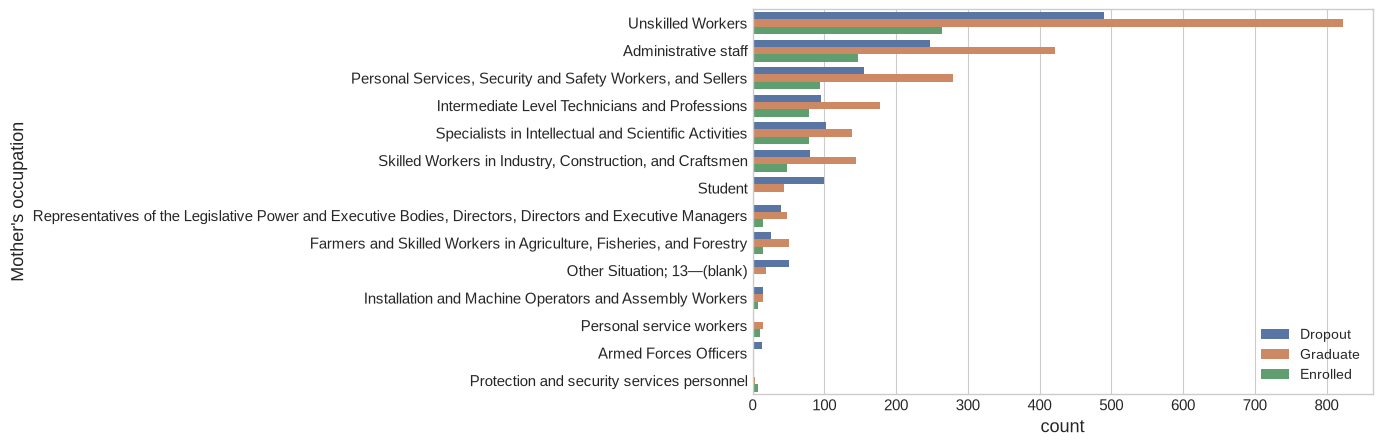

In [170]:
label_counts = eda['mo_labels'].value_counts()
labels_to_keep = label_counts[label_counts >= 10].index
filtered_eda = eda[eda['mo_labels'].isin(labels_to_keep)]

plt.figure(figsize=(8, 5))
sns.countplot(
    y='mo_labels',
    hue='Target',
    data=filtered_eda,
    palette=palette,
    order=labels_to_keep
)
plt.ylabel("Mother's occupation")
plt.legend(loc=4)
plt.show()

Most female progenitors occupation are Unskilled Workers, Administrative staff and Personal Services, sellers and Security-Safe Workers.

There's a **prevalence in dropouts** of stutends whose mothers are also **studying.**

* `Father's Occupation`

Labels are the same as before, +10 entries are represented.

In [171]:
invalid = eda[~eda["Father's occupation"].between(1, len(occupation_labels))]
print(invalid["Father's occupation"].value_counts())

Father's occupation
46    1
Name: count, dtype: int64


There's an misslabeled entry for Father's Occupation (46 and there're only 45 labels). To deal with that a new label **Unknown** will be added.

In [172]:
foccupation_labels = [
    "Student",
    "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
    "Specialists in Intellectual and Scientific Activities",
    "Intermediate Level Technicians and Professions",
    "Administrative staff",
    "Personal Services, Security and Safety Workers, and Sellers",
    "Farmers and Skilled Workers in Agriculture, Fisheries, and Forestry",
    "Skilled Workers in Industry, Construction, and Craftsmen",
    "Installation and Machine Operators and Assembly Workers",
    "Unskilled Workers",
    "Armed Forces Professions",
    "Other Situation; 13—(blank)",
    "Armed Forces Officers",
    "Armed Forces Sergeants",
    "Other Armed Forces personnel",
    "Directors of administrative and commercial services",
    "Hotel, catering, trade, and other services directors",
    "Specialists in the physical sciences, mathematics, engineering, and related techniques",
    "Health professionals",
    "Teachers",
    "Specialists in finance, accounting, administrative organization, and public and commercial relations",
    "Intermediate level science and engineering technicians and professions",
    "Technicians and professionals of intermediate level of health",
    "Intermediate level technicians from legal, social, sports, cultural, and similar services",
    "Information and communication technology technicians",
    "Office workers, secretaries in general, and data processing operators",
    "Data, accounting, statistical, financial services, and registry-related operators",
    "Other administrative support staff",
    "Personal service workers",
    "Sellers",
    "Personal care workers and the like",
    "Protection and security services personnel",
    "Market-oriented farmers and skilled agricultural and animal production workers",
    "Farmers, livestock keepers, fishermen, hunters and gatherers, and subsistence",
    "Skilled construction workers and the like, except electricians",
    "Skilled workers in metallurgy, metalworking, and similar",
    "Skilled workers in electricity and electronics",
    "Workers in food processing, woodworking, and clothing and other industries and crafts",
    "Fixed plant and machine operators",
    "Assembly workers",
    "Vehicle drivers and mobile equipment operators",
    "Unskilled workers in agriculture, animal production, and fisheries and forestry",
    "Unskilled workers in extractive industry, construction, manufacturing, and transport",
    "Meal preparation assistants",
    "Street vendors (except food) and street service provider",
    "Unknown"
]

eda['fo_labels'] = eda['Father\'s occupation'].map(lambda x: foccupation_labels[x - 1])
eda['fo_labels'].value_counts()

fo_labels
Unskilled Workers                                                                                             1010
Skilled Workers in Industry, Construction, and Craftsmen                                                       666
Personal Services, Security and Safety Workers, and Sellers                                                    516
Administrative staff                                                                                           386
Intermediate Level Technicians and Professions                                                                 384
Installation and Machine Operators and Assembly Workers                                                        318
Armed Forces Professions                                                                                       266
Farmers and Skilled Workers in Agriculture, Fisheries, and Forestry                                            242
Specialists in Intellectual and Scientific Activities                 

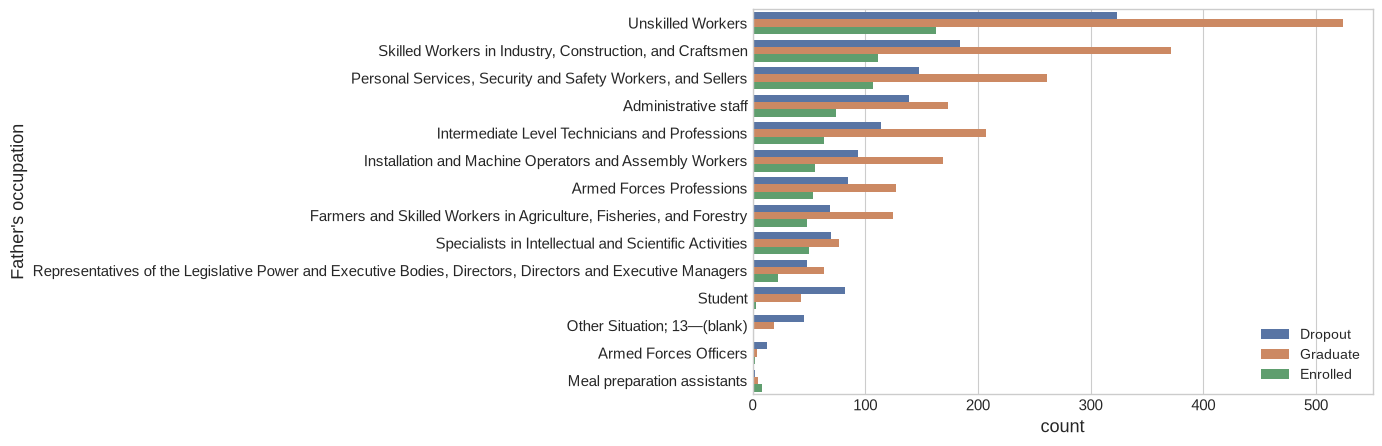

In [173]:
label_counts = eda['fo_labels'].value_counts()
labels_to_keep = label_counts[label_counts >= 10].index
filtered_eda = eda[eda['fo_labels'].isin(labels_to_keep)]

plt.figure(figsize=(8, 5))
sns.countplot(
    y='fo_labels',
    hue='Target',
    data=filtered_eda,
    palette=palette,
    order=labels_to_keep
)
plt.ylabel("Father's occupation")
plt.legend(loc=4)
plt.show()

Similar to Mother's Occupation, prevalent occupations are Unskilled Workers, Personal Services, Sellers, Security-Safety Workers and the addition of occupation in Industry, Construction and Craftsmen.

**Dropouts** stand more with fathers that are also **studying.**

* `Displaced`

In [174]:
print(eda['Displaced'].value_counts())
print((eda.Displaced ==1).sum() / len(eda) * 100)

Displaced
1    2426
0    1998
Name: count, dtype: int64
54.8372513562387


**54.84%** of the students are considered **displaced.**

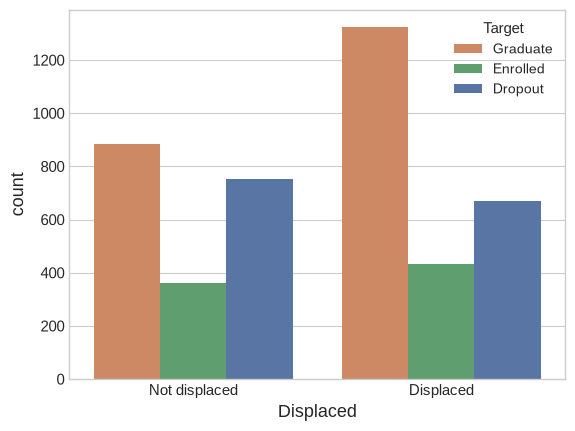

In [175]:
ax = plt.subplot()
sns.countplot(x='Displaced', hue='Target', data=eda, palette=palette)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not displaced', 'Displaced'])
plt.show()

* `Educational Special Needs`

In [176]:
print(eda['Educational special needs'].value_counts())
print((eda['Educational special needs'] ==1).sum() / len(eda) * 100)

Educational special needs
0    4373
1      51
Name: count, dtype: int64
1.1528028933092225


Only **1.15%** of the students have **Educational Special needs.**

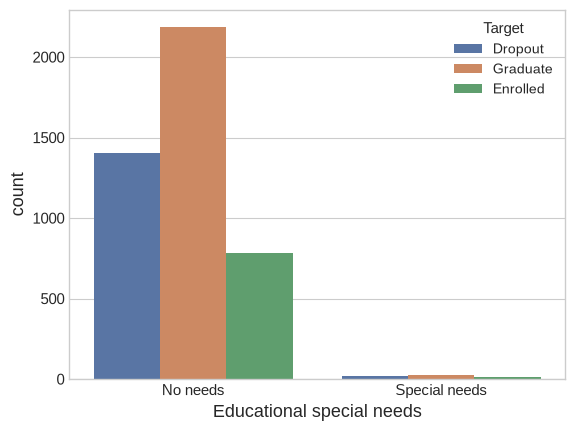

In [177]:
ax = plt.subplot()
sns.countplot(x='Educational special needs', hue='Target', data=eda, palette=palette)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No needs', 'Special needs'])
plt.show()

* `Debtor`

In [178]:
print(eda['Debtor'].value_counts())
print((eda['Debtor'] ==1).sum() / len(eda) * 100)

Debtor
0    3921
1     503
Name: count, dtype: int64
11.369801084990959


11.37% of students are classified as debtors.

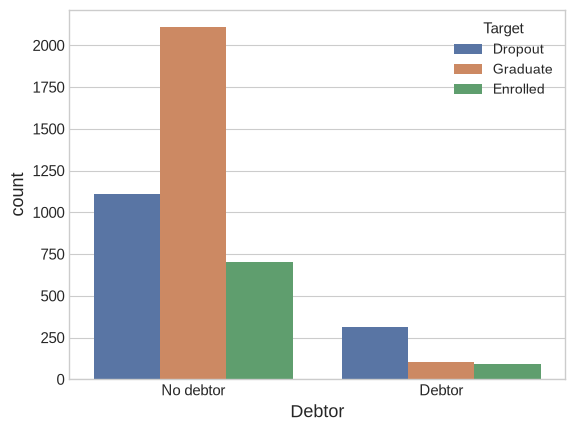

In [179]:
ax = plt.subplot()
sns.countplot(x='Debtor', hue='Target', data=eda, palette=palette)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No debtor', 'Debtor'])
plt.show()

Most dropout students are classified as **debtors.**

* `Tuition Fees up to date`

In [180]:
print(eda['Tuition fees up to date'].value_counts())
print((eda['Tuition fees up to date'] ==1).sum() / len(eda) * 100)

Tuition fees up to date
1    3896
0     528
Name: count, dtype: int64
88.06509945750453


**88%** of the students have paid the tuition fees.

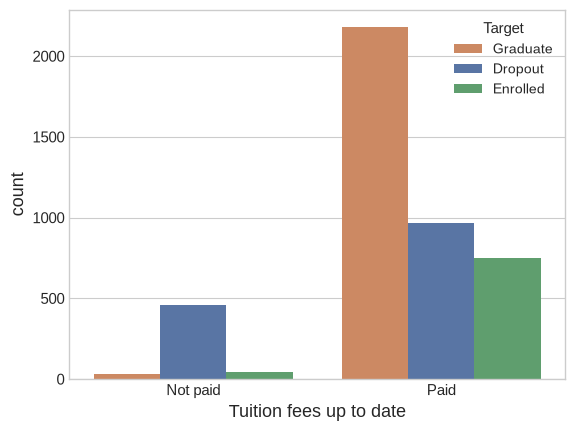

In [181]:
ax = plt.subplot()
sns.countplot(x='Tuition fees up to date', hue='Target', data=eda, palette=palette)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not paid', 'Paid'])
plt.show()

Most of the students that didn't pay the **Tuition Fees** are classified as dropouts.

* `Gender`

In [182]:
print(eda['Gender'].value_counts())
print('Female\'s Percentage:')
print((eda['Gender'] ==1).sum() / len(eda) * 100)
print('Male\'s Percentage:')
print((eda['Gender'] ==0).sum() / len(eda) * 100)

Gender
0    2868
1    1556
Name: count, dtype: int64
Female's Percentage:
35.171790235081374
Male's Percentage:
64.82820976491863


The majority of the students from the dataset are **male (64.83 %)**, being **female 35.17%.**

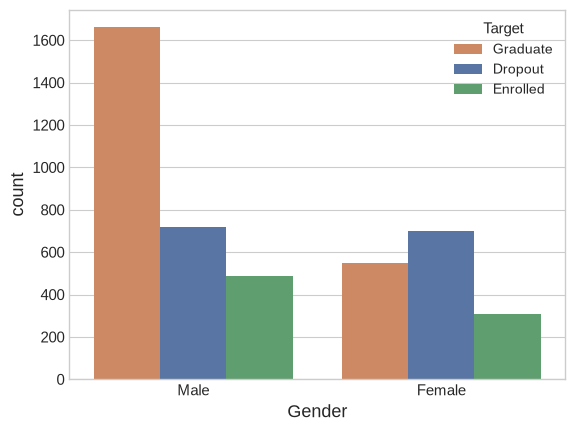

In [183]:
ax = plt.subplot()
sns.countplot(x='Gender', hue='Target', data=eda, palette=palette)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Male', 'Female'])
plt.show()

The majority of **female students** are classified as **dropouts.**

* `Scholarship holder`

In [184]:
print(eda['Scholarship holder'].value_counts())
print((eda['Scholarship holder'] ==1).sum() / len(eda) * 100)

Scholarship holder
0    3325
1    1099
Name: count, dtype: int64
24.841772151898734


24.84% of students receivied a scolarship.

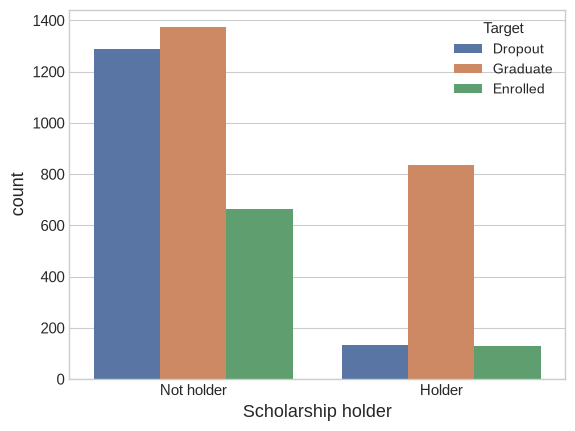

In [185]:
ax = plt.subplot()
sns.countplot(x='Scholarship holder', hue='Target', data=eda, palette=palette)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not holder', 'Holder'])
plt.show()

* `Age at enrollment`

In [186]:
print(eda['Age at enrollment'].value_counts())
print('Maximum age at enrollment:', eda['Age at enrollment'].max())


Age at enrollment
18    1036
19     911
20     599
21     322
22     174
24     131
23     108
26      94
25      93
27      91
28      83
29      66
32      61
34      60
31      55
35      49
30      49
33      45
37      42
39      38
36      35
41      31
38      29
43      25
40      23
45      22
44      21
47      18
50      16
42      13
49      13
46      12
48      11
53       7
51       7
54       7
55       5
17       5
52       4
58       3
59       3
60       2
57       2
70       1
61       1
62       1
Name: count, dtype: int64
Maximum age at enrollment: 70


Most frecuent enrollment ages go from 18-23. There's a high variety being the maximum age 70.

<Axes: xlabel='Age at enrollment', ylabel='count'>

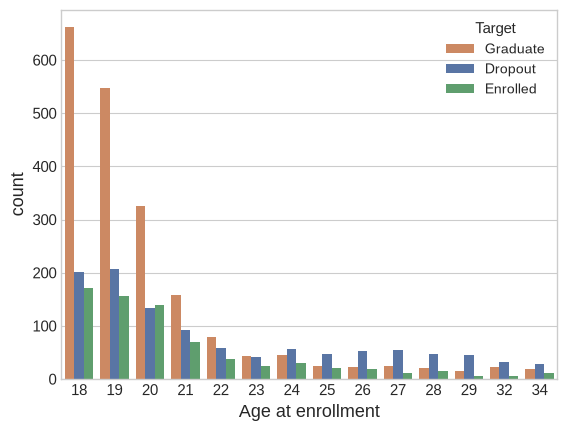

In [187]:
label_counts = eda['Age at enrollment'].value_counts()
labels_to_keep = label_counts[label_counts >= 60].index
filtered_eda = eda[eda['Age at enrollment'].isin(labels_to_keep)]
sns.countplot(x='Age at enrollment', hue='Target', data=filtered_eda, palette=palette)

The older the age at enrollment gets, dropout rate increases, surpasing the graduation rate, starting at 24 years old.

* `International`

In [188]:
print(eda['International'].value_counts())
print((eda['International'] ==1).sum() / len(eda) * 100)

International
0    4314
1     110
Name: count, dtype: int64
2.4864376130198913


Only 2.49% of the students are international students.

([<matplotlib.axis.XTick at 0x777ae197eae0>],
 [Text(0, 0, 'International Students')])

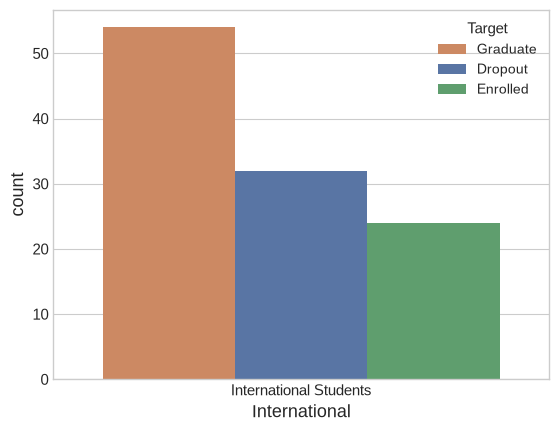

In [189]:

filtered_eda = eda[eda['International'] == 1]
sns.countplot(x='International', hue='Target', data=filtered_eda, palette=palette)
plt.xticks([0], ['International Students'])

* `Curricular units first sem (credited)`

In [190]:
eda['Curricular units 1st sem (credited)'].value_counts()

Curricular units 1st sem (credited)
0     3847
2       94
1       85
3       69
6       51
4       47
7       41
5       41
8       31
9       27
11      17
10      15
14      15
13      13
12      12
15       5
18       4
17       3
16       3
19       2
20       2
Name: count, dtype: int64

Most students do not have credited units. As this is the majority, it is represented the count of students that have at least 1 unit credited to analyze any possible trend in Graduate/Droptout.

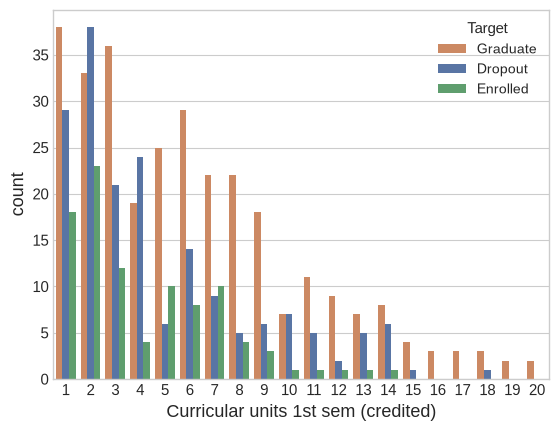

In [191]:
filtered_eda = eda[eda['Curricular units 1st sem (credited)'] >= 1]
sns.countplot(x='Curricular units 1st sem (credited)', hue='Target', data=filtered_eda, palette=palette)
plt.show()

Students that have 2 or 4 units credited tend to be Dropouts.

* `Curricular units first sem (enrolled)`

In [192]:
print(eda['Curricular units 1st sem (enrolled)'].value_counts())
print((eda['Curricular units 1st sem (enrolled)'] ==6).sum() / len(eda) * 100)
print((eda['Curricular units 1st sem (enrolled)'] ==5).sum() / len(eda) * 100)
print((eda['Curricular units 1st sem (enrolled)'] ==7).sum() / len(eda) * 100)

Curricular units 1st sem (enrolled)
6     1910
5     1010
7      656
8      296
0      180
12      66
10      52
11      45
9       36
15      25
14      22
4       21
13      20
18      19
17      16
16      13
3       10
2        9
1        7
21       6
19       2
23       2
26       1
Name: count, dtype: int64
43.173598553345386
22.83001808318264
14.828209764918626


**43.17%** of students enroll in 6 units in their first semester, followed by **22.83%** with 5 units enrolled and **14.83%** with 7 units enrolled.

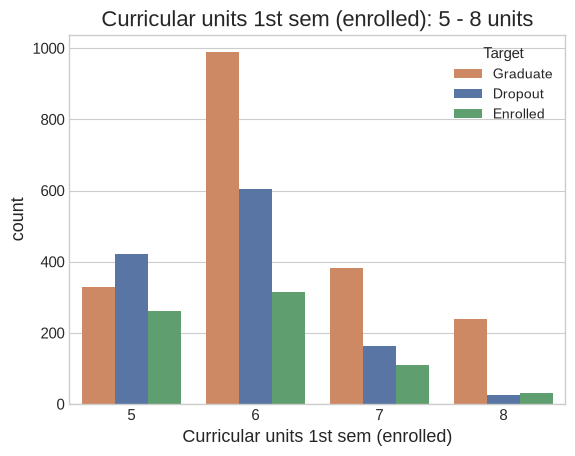

In [193]:
filtered_eda1 = eda[(eda['Curricular units 1st sem (enrolled)'] >= 5) &
                    (eda['Curricular units 1st sem (enrolled)'] <= 8)]
sns.countplot(x='Curricular units 1st sem (enrolled)', hue='Target', data=filtered_eda1, palette=palette)
plt.title('Curricular units 1st sem (enrolled): 5 - 8 units')
plt.show()

The majority of students enroll from 5 to 8 units in the 1st semester. The dropout rate is above the graduate one only on students that enroll in 5 units.

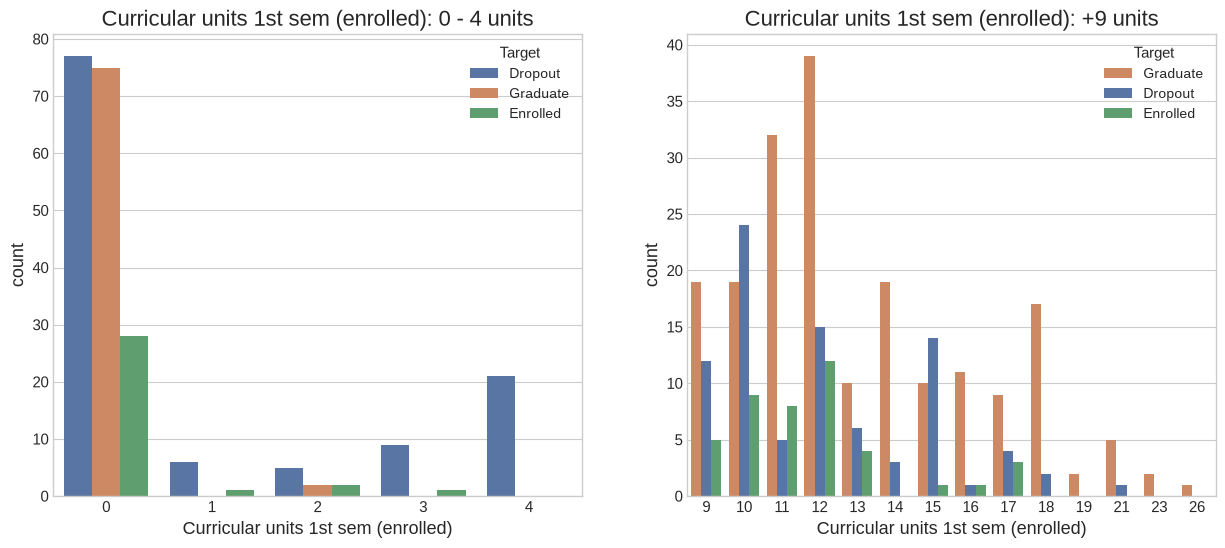

In [194]:
filtered_eda2 = eda[(eda['Curricular units 1st sem (enrolled)'] < 5)]
filtered_eda3 = eda[(eda['Curricular units 1st sem (enrolled)'] > 8)]

fig = plt.subplots(1,2, figsize=(15,6))
plt.subplot(1, 2, 1)
sns.countplot(x='Curricular units 1st sem (enrolled)', hue='Target', data=filtered_eda2, palette=palette)
plt.title('Curricular units 1st sem (enrolled): 0 - 4 units')

plt.subplot(1, 2, 2)
sns.countplot(x='Curricular units 1st sem (enrolled)', hue='Target', data=filtered_eda3, palette=palette)
plt.title('Curricular units 1st sem (enrolled): +9 units')
plt.show()

Students that enroll in **less than 5 units** tend to be dropouts.

Students that enroll in **more than 8 units** tend to graduate, only being the dropout rate superior in students enrolled in 10 adn 15 units.

* `Curricular units 1st sem (evaluations)`

In [195]:
print(eda['Curricular units 1st sem (evaluations)'].value_counts())
print(eda['Curricular units 1st sem (evaluations)'].nunique())
print((eda['Curricular units 1st sem (evaluations)'] ==8).sum() / len(eda) * 100)
print((eda['Curricular units 1st sem (evaluations)'] ==7).sum() / len(eda) * 100)


Curricular units 1st sem (evaluations)
8     791
7     703
6     598
9     402
0     349
10    340
11    239
12    223
5     220
13    140
14    105
15     70
16     47
17     33
18     30
19     23
4      19
21     17
20     12
22     10
23      9
2       8
1       6
3       6
24      6
26      4
25      3
45      2
29      2
27      2
36      1
32      1
31      1
28      1
33      1
Name: count, dtype: int64
35
17.87974683544304
15.890596745027125


There's a high variety in the evaluations of the first semester's units (35). Major values are 8 units (17.88%) and 7 units (15.89%).

The graphic representation includes values of +100 count of students.

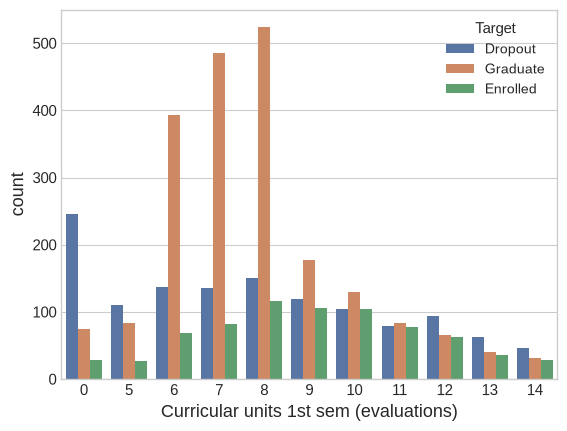

In [196]:
label_counts = eda['Curricular units 1st sem (evaluations)'].value_counts()
labels_to_keep = label_counts[label_counts >= 100].index
filtered_eda = eda[eda['Curricular units 1st sem (evaluations)'].isin(labels_to_keep)]
sns.countplot(x='Curricular units 1st sem (evaluations)', hue='Target', data=filtered_eda, palette=palette)
plt.show()

Most students with **0 units evaluated** are labelled as dropouts. That happens also with **+12 units evaluated**, however the disparity is way lower.

* `Curricular units first sem (approved)`

In [197]:
print(eda['Curricular units 1st sem (approved)'].value_counts())
print((eda['Curricular units 1st sem (approved)'] ==6).sum() / len(eda) * 100)
print((eda['Curricular units 1st sem (approved)'] ==0).sum() / len(eda) * 100)

Curricular units 1st sem (approved)
6     1171
5      723
0      718
7      471
4      433
3      269
2      160
1      127
8      108
11      49
12      44
9       40
13      26
10      24
18      15
14      14
17      10
15       7
16       5
21       4
20       3
19       2
26       1
Name: count, dtype: int64
26.469258589511753
16.229656419529835


26.47% of the students **pass 6 units** in their first semester. 16.23% of the students **don't pass any unit at all**, being the 3rd highest percentage from all the students.

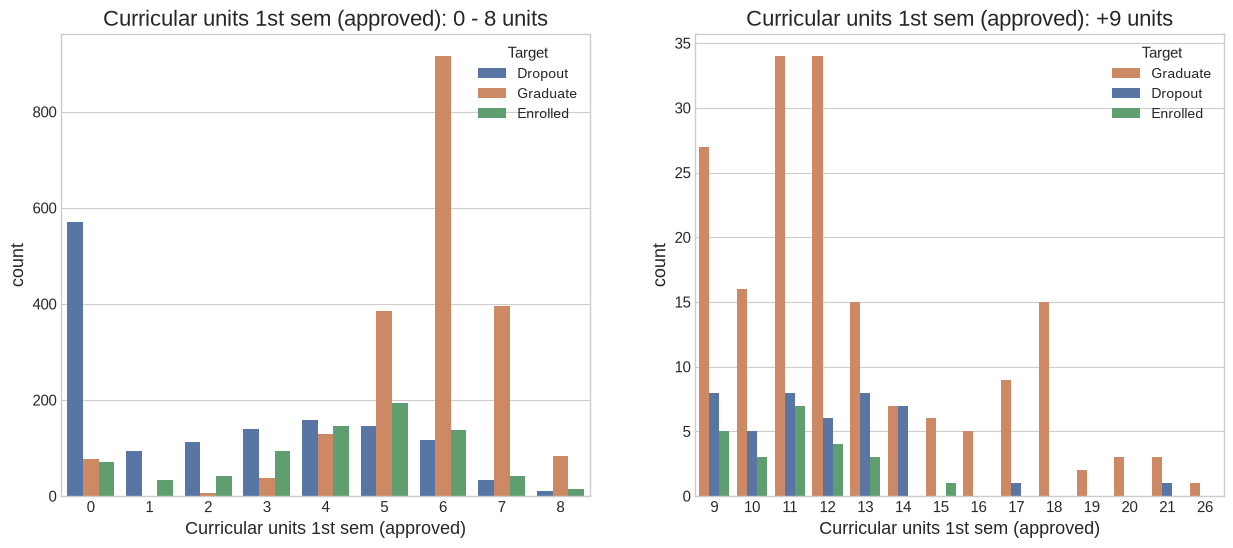

In [198]:
filtered_eda2 = eda[(eda['Curricular units 1st sem (approved)'] <= 8)]
filtered_eda3 = eda[(eda['Curricular units 1st sem (approved)'] > 8)]

fig = plt.subplots(1,2, figsize=(15,6))
plt.subplot(1, 2, 1)
sns.countplot(x='Curricular units 1st sem (approved)', hue='Target', data=filtered_eda2, palette=palette)
plt.title('Curricular units 1st sem (approved): 0 - 8 units')

plt.subplot(1, 2, 2)
sns.countplot(x='Curricular units 1st sem (approved)', hue='Target', data=filtered_eda3, palette=palette)
plt.title('Curricular units 1st sem (approved): +9 units')
plt.show()

Students that pass **less than 5 units** in the 1st semester tend to be the majority dropouts. On the other hand students that **pass +5** units tend to be graduates minus students that approve 14 units, that are 50/50 graduates - dropouts.

* `Curricular units 1st sem (without evaluations)`

In [199]:
print(eda['Curricular units 1st sem (without evaluations)'].value_counts())
print((eda['Curricular units 1st sem (without evaluations)'] ==0).sum() / len(eda) * 100)


Curricular units 1st sem (without evaluations)
0     4130
1      153
2       79
3       23
4       15
6        6
7        6
5        5
8        4
12       2
10       1
Name: count, dtype: int64
93.35443037974683


93.35% of the students get all their units evaluated.

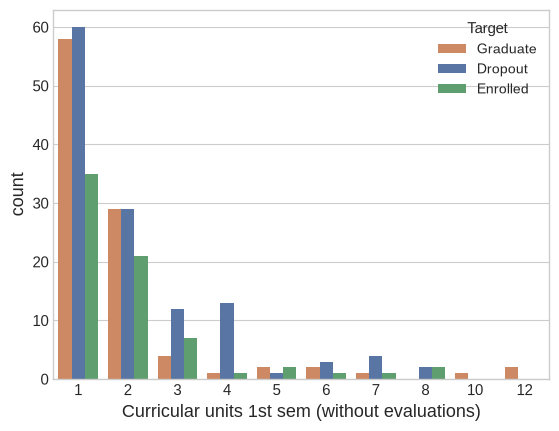

In [200]:
filtered_eda = eda[(eda['Curricular units 1st sem (without evaluations)'] >= 1)]
sns.countplot(x='Curricular units 1st sem (without evaluations)', hue='Target', data=filtered_eda, palette=palette)
plt.show()

Most students that had a **unit or more not evaluated** were dropouts, only didn't students that had 2 units not evaluated (50/50 graduate - dropout) and 2 students that had 12 not evaluated.

* `Curricular units 2nd sem (credited)`

In [201]:
eda['Curricular units 2nd sem (credited)'].value_counts()

Curricular units 2nd sem (credited)
0     3894
1      107
2       92
4       78
5       68
3       49
6       26
11      20
7       16
9       15
12      14
10      13
8       12
13       9
14       4
15       2
16       2
18       2
19       1
Name: count, dtype: int64

Similar as the first semester, the majority of students don't have credited units alreade. The representation is done for students that have at least 1 unit credited.

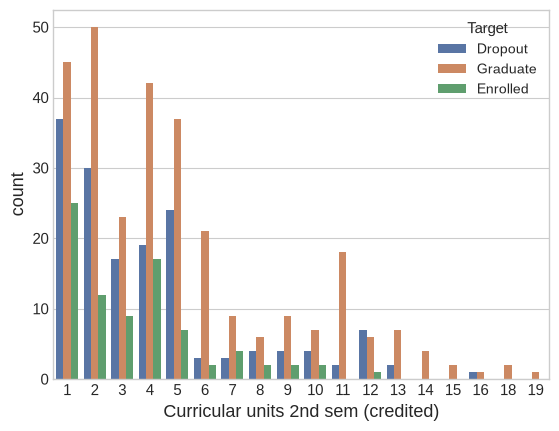

In [202]:
filtered_eda = eda[eda['Curricular units 2nd sem (credited)'] >= 1]
sns.countplot(x='Curricular units 2nd sem (credited)', hue='Target', data=filtered_eda, palette=palette)
plt.show()

Students that have 12 units credited in the second semester are the majority labelled as dropouts.

* `Curricular units 2nd semester (enrolled)`

In [203]:
print(eda['Curricular units 2nd sem (enrolled)'].value_counts())
print((eda['Curricular units 2nd sem (enrolled)'] ==6).sum() / len(eda) * 100)
print((eda['Curricular units 2nd sem (enrolled)'] ==5).sum() / len(eda) * 100)

Curricular units 2nd sem (enrolled)
6     1913
5     1054
8      661
7      304
0      180
11      60
9       50
10      48
12      44
13      37
14      22
4       17
17      12
2        5
19       3
3        3
1        3
15       2
23       2
18       2
16       1
21       1
Name: count, dtype: int64
43.24141048824593
23.824593128390596


**43.24%** of students enroll in 6 units in their first semester, followed by **23.82%** with 5 units enrolled. This is similar to the behaviour of the first semester.

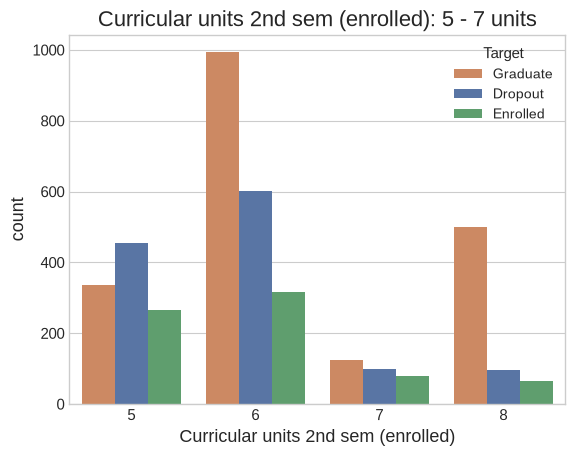

In [204]:
filtered_eda1 = eda[(eda['Curricular units 2nd sem (enrolled)'] >= 5) &
                    (eda['Curricular units 2nd sem (enrolled)'] <= 8)]
sns.countplot(x='Curricular units 2nd sem (enrolled)', hue='Target', data=filtered_eda1, palette=palette)
plt.title('Curricular units 2nd sem (enrolled): 5 - 7 units')
plt.show()

The majority of students enroll from 5 to 7 units in the 1st semester. The dropout rate is above the graduate one only on students that enroll in 5 units (same tendency as the first semester).

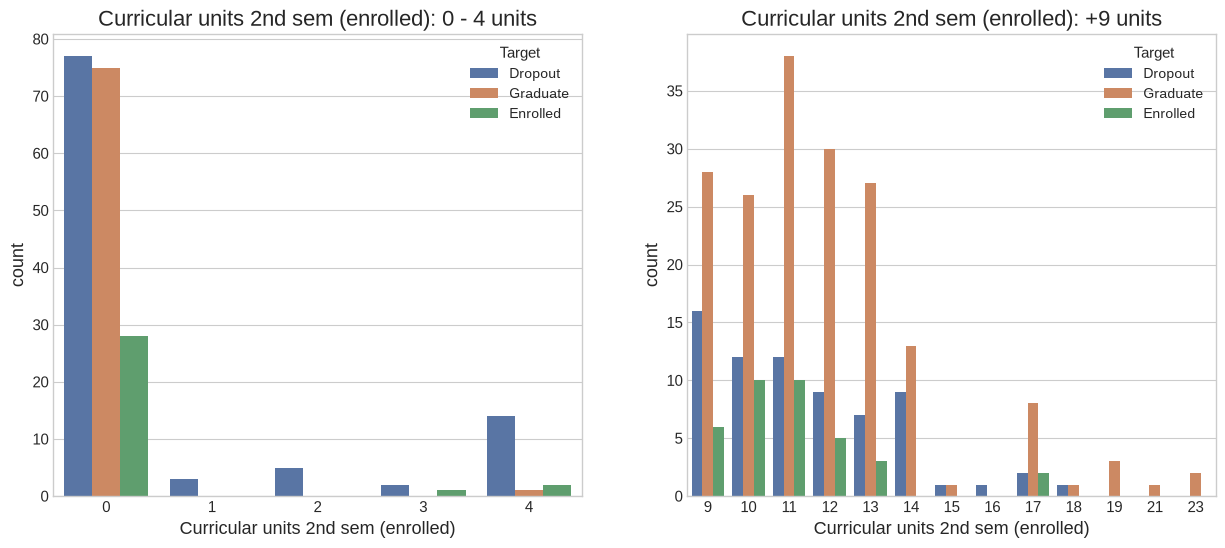

In [205]:
filtered_eda2 = eda[(eda['Curricular units 2nd sem (enrolled)'] < 5)]
filtered_eda3 = eda[(eda['Curricular units 2nd sem (enrolled)'] > 8)]

fig = plt.subplots(1,2, figsize=(15,6))
plt.subplot(1, 2, 1)
sns.countplot(x='Curricular units 2nd sem (enrolled)', hue='Target', data=filtered_eda2, palette=palette)
plt.title('Curricular units 2nd sem (enrolled): 0 - 4 units')

plt.subplot(1, 2, 2)
sns.countplot(x='Curricular units 2nd sem (enrolled)', hue='Target', data=filtered_eda3, palette=palette)
plt.title('Curricular units 2nd sem (enrolled): +9 units')
plt.show()

Students that enroll in **less than 5 units** tend to be dropouts. The dropout range is similar to the first semester in this range.

Students that enroll in **more than 8 units** tend to graduate, only being the dropout rate superior in students enrolled in 16 units. The dropout rate is inferior to the first semester in this range.

* `Curricular units 2nd semester (evaluations)`

In [206]:
print(eda['Curricular units 2nd sem (evaluations)'].value_counts())
print((eda['Curricular units 2nd sem (evaluations)'] ==8).sum() / len(eda) * 100)
print((eda['Curricular units 2nd sem (evaluations)'] ==6).sum() / len(eda) * 100)

Curricular units 2nd sem (evaluations)
8     792
6     614
7     563
9     456
0     401
10    355
5     288
11    255
12    226
13    126
14     98
15     73
16     49
17     25
18     22
19     19
4      10
21     10
22     10
20      8
2       4
23      4
1       3
26      3
24      3
3       2
27      2
28      1
25      1
33      1
Name: count, dtype: int64
17.90235081374322
13.87884267631103


Same as first semester, there's a high variety in the units evaluated. Major values are **8 units (17.9%)** and **6 units (13.88%).**

The graphic representation includes values of +100 count of students.

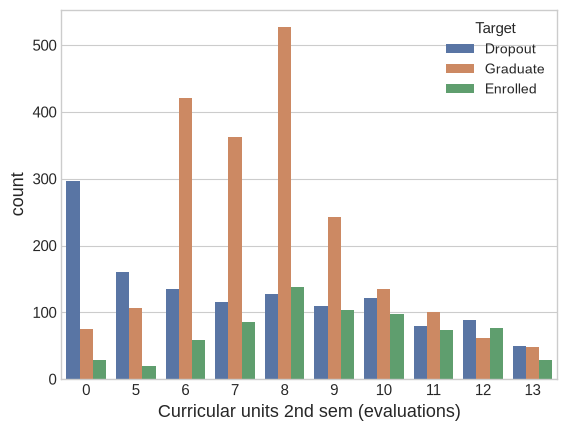

In [207]:
label_counts = eda['Curricular units 2nd sem (evaluations)'].value_counts()
labels_to_keep = label_counts[label_counts >= 100].index
filtered_eda = eda[eda['Curricular units 2nd sem (evaluations)'].isin(labels_to_keep)]
sns.countplot(x='Curricular units 2nd sem (evaluations)', hue='Target', data=filtered_eda, palette=palette)
plt.show()

Most students with **0, 5 units evaluated** are labelled as dropouts. That happens also with **+12 units evaluated**, however the disparity is way lower. The trend is similar as the first semester.

* `Curricular units 2nd semester (approved)`

In [208]:
print(eda['Curricular units 2nd sem (approved)'].value_counts())
print((eda['Curricular units 2nd sem (approved)'] ==6).sum() / len(eda) * 100)
print((eda['Curricular units 2nd sem (approved)'] ==0).sum() / len(eda) * 100)

Curricular units 2nd sem (approved)
6     965
0     870
5     726
4     414
7     331
8     321
3     285
2     198
1     114
11     48
10     38
9      36
12     34
13     21
17      8
14      6
19      3
20      2
16      2
18      2
Name: count, dtype: int64
21.812839059674502
19.665461121157325


21.81% of the students **pass 6 units** in their first semester, lower percentage as first semester. 19.67% of the students **don't pass any unit at all**, being the 2nd highest percentage from all the students, and higher compared to the percentage of students that didn't pass any unit in the first semester.

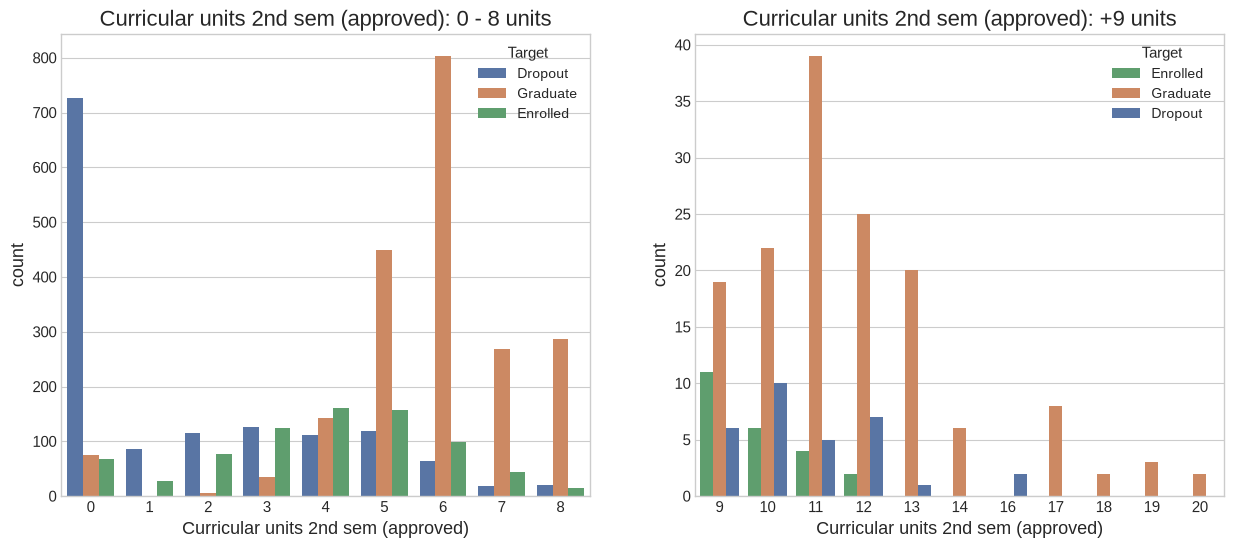

In [209]:
filtered_eda2 = eda[(eda['Curricular units 2nd sem (approved)'] <= 8)]
filtered_eda3 = eda[(eda['Curricular units 2nd sem (approved)'] > 8)]

fig = plt.subplots(1,2, figsize=(15,6))
plt.subplot(1, 2, 1)
sns.countplot(x='Curricular units 2nd sem (approved)', hue='Target', data=filtered_eda2, palette=palette)
plt.title('Curricular units 2nd sem (approved): 0 - 8 units')

plt.subplot(1, 2, 2)
sns.countplot(x='Curricular units 2nd sem (approved)', hue='Target', data=filtered_eda3, palette=palette)
plt.title('Curricular units 2nd sem (approved): +9 units')
plt.show()

Students that pass **less than 4 units** in the 2nd semester tend to be the majority dropouts. On the other hand students that **pass +5** units tend to be graduates minus students that approve 16 units, that are only dropouts (just 2 students).

* `Curricular units 2nd semester (without evaluations)`

In [210]:
print(eda['Curricular units 2nd sem (without evaluations)'].value_counts())
print((eda['Curricular units 2nd sem (without evaluations)'] ==0).sum() / len(eda) * 100)

Curricular units 2nd sem (without evaluations)
0     4142
1      140
2       48
3       35
4       21
5       17
6        8
8        6
7        5
12       2
Name: count, dtype: int64
93.625678119349


93.63% of the students get all their units evaluated, slighty higher percentage than first semester.

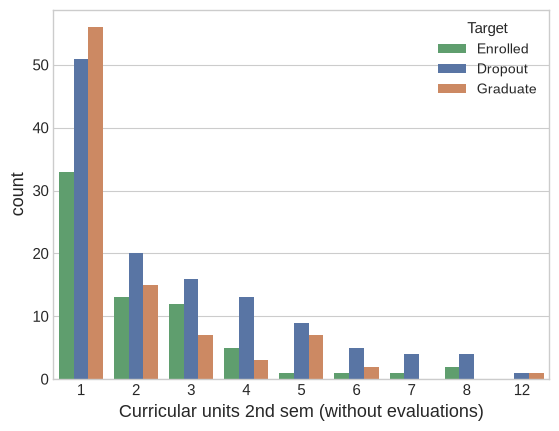

In [211]:
filtered_eda = eda[(eda['Curricular units 2nd sem (without evaluations)'] >= 1)]
sns.countplot(x='Curricular units 2nd sem (without evaluations)', hue='Target', data=filtered_eda, palette=palette)
plt.show()

Most students that had a **two units or more not evaluated** were dropouts, only didn't students that had 12 units not evaluated (50/50 graduate - dropout).

* `Unemployment rate`

In [212]:
print(eda['Unemployment rate'].describe())
print('-------------------------------------')
print(eda['Unemployment rate'].value_counts())
print('-------------------------------------')
print(eda['Unemployment rate'].info())
print(eda['Unemployment rate'].nunique())

count    4424.000000
mean       11.566139
std         2.663850
min         7.600000
25%         9.400000
50%        11.100000
75%        13.900000
max        16.200000
Name: Unemployment rate, dtype: float64
-------------------------------------
Unemployment rate
7.6     571
9.4     533
10.8    525
12.4    445
12.7    419
11.1    414
15.5    397
13.9    390
8.9     368
16.2    362
Name: count, dtype: int64
-------------------------------------
<class 'pandas.Series'>
RangeIndex: 4424 entries, 0 to 4423
Series name: Unemployment rate
Non-Null Count  Dtype  
--------------  -----  
4424 non-null   float64
dtypes: float64(1)
memory usage: 34.7 KB
None
10


The unemployment rate consists in 10 floating numbers varying from 7.6 to 16.2, probably the recorded unemployment rate for the periods of acceptance for new students, consisting in 10 periods according to the 10 different values of unemployment rate.

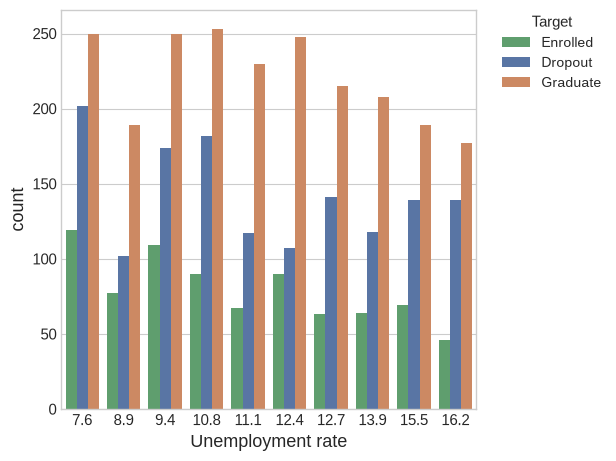

In [213]:
sns.countplot(x='Unemployment rate', hue='Target', data=eda, palette=palette)
plt.legend(title="Target", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

* `Inflation rate`

In [214]:
print(eda['Inflation rate'].describe())
print('-------------------------------------')
print(eda['Inflation rate'].value_counts())
print('-------------------------------------')
print(eda['Inflation rate'].info())
print(eda['Inflation rate'].nunique())

count    4424.000000
mean        1.228029
std         1.382711
min        -0.800000
25%         0.300000
50%         1.400000
75%         2.600000
max         3.700000
Name: Inflation rate, dtype: float64
-------------------------------------
Inflation rate
 1.4    893
 2.6    571
-0.8    533
 0.5    445
 3.7    419
 0.6    414
 2.8    397
-0.3    390
 0.3    362
Name: count, dtype: int64
-------------------------------------
<class 'pandas.Series'>
RangeIndex: 4424 entries, 0 to 4423
Series name: Inflation rate
Non-Null Count  Dtype  
--------------  -----  
4424 non-null   float64
dtypes: float64(1)
memory usage: 34.7 KB
None
9


The inflation rate consists in 9 floating numbers varying from -0.8 to 3.7. Same as with the unemployment rate, it would be the recorded rate at the period of the student's enrollment, in this case there're 9 unique values compared to the unemployment rate of 10. This could mean that there were two periods of enrollment with the exact same inflation rate, probably for the **1.4** value, which count is almost double as the second higher count value.

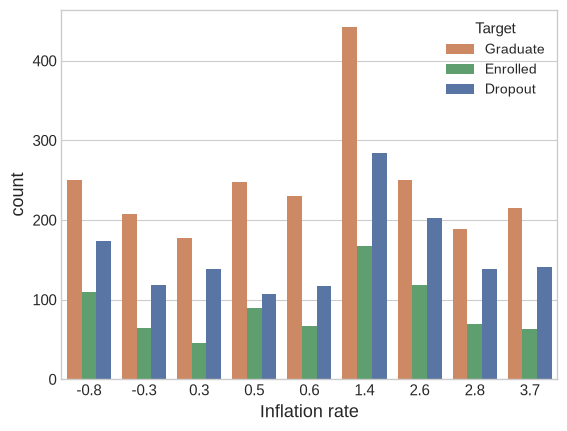

In [215]:
sns.countplot(x='Inflation rate', hue='Target', data=eda, palette=palette)
plt.show()

* `GDP`

In [216]:
print(eda['GDP'].describe())
print('-------------------------------------')
print(eda['GDP'].value_counts())
print('-------------------------------------')
print(eda['GDP'].info())
print(eda['GDP'].nunique())

count    4424.000000
mean        0.001969
std         2.269935
min        -4.060000
25%        -1.700000
50%         0.320000
75%         1.790000
max         3.510000
Name: GDP, dtype: float64
-------------------------------------
GDP
 0.32    571
-3.12    533
 1.74    525
 1.79    445
-1.70    419
 2.02    414
-4.06    397
 0.79    390
 3.51    368
-0.92    362
Name: count, dtype: int64
-------------------------------------
<class 'pandas.Series'>
RangeIndex: 4424 entries, 0 to 4423
Series name: GDP
Non-Null Count  Dtype  
--------------  -----  
4424 non-null   float64
dtypes: float64(1)
memory usage: 34.7 KB
None
10


GDP variable behaves in a similar way of Inflation/Unemployment rate, with 10 different rates probably recorded at the period of the student's enrollment.

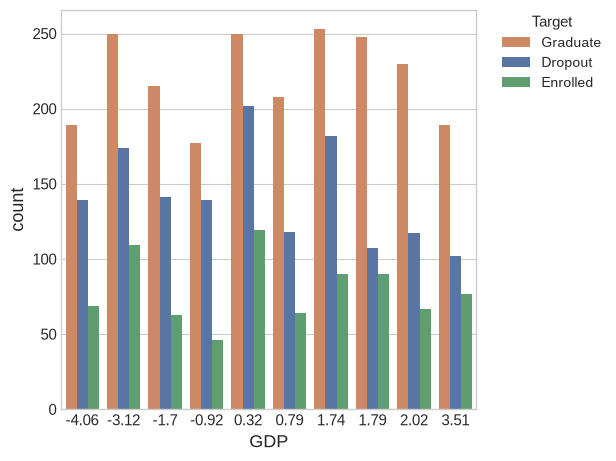

In [217]:
sns.countplot(x='GDP', hue='Target', data=eda, palette=palette)
plt.legend(title="Target", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

## Analysis Summary:
### Target Variable (Graduate, Dropout, Enrolled)
- **Distribution:**
  - Graduate: 49.9%
  - Dropout: 32.1%
  - Enrolled: 17.9%
- **Implication:** The dataset is imbalanced, with Graduates being the majority. Special attention is needed for model training to address this imbalance.

---

### Key Demographics & Social Factors

- **Marital Status**

  - **Majority Single:** 88.6% of students are single.

  - **Dropout Tendency:** Dropouts are more prevalent in non-single categories.

* **Gender**

  - **Male Dominance:** 64.8% male, 35.2% female.

  - **Dropout Pattern:** Female students exhibit a higher dropout rate than males.

* **Age at Enrollment**

  - **Typical Age:** Most enrollments occur between 18-23 years.

  - **Dropout Risk:** Dropout rates rise significantly for students enrolling at 24+ years.

* **Nationality**

  - **Predominantly Portuguese:** 97.5% Portuguese, very few international students (2.5%).

---

### Academic Pathways & Performance

* **Application/Entry**

  - **First Choice:** 68.4% of students applied as their first choice.

  - **Over 23 Years Old:** This group shows a higher dropout rate.

* **Course**

  - **Top Courses:** Nursing, Management, and Social Service have the most students.

  - **High Dropout:** Equiniculture, Informatics Engineering, and Management (evening) show elevated dropout rates.

* **Previous Qualifications**

  - **Most from Secondary Education:** Students with only basic education (3rd cycle) have higher dropout rates.

---

### Family Background

* **Parental Education**

  - **Mother:** Most have secondary education or commerce-related qualifications.

  - **Father:** Most have basic education (1st or 3rd cycle).

* **Parental Occupation**

  - **Mother:** Most common occupations are Unskilled Workers, Administrative Staff, and Personal Services/Sellers.

  - **Father:** Similar, with the addition of Skilled Industry/Construction. Dropouts are more frequent when parents are also students.

---

### Socioeconomic Factors

* **Displaced Students**

  - **54.8% Displaced:** These students live away from home for their studies.

* **Debtor & Tuition**

  - **Debtors:** 11.4% of students are debtors, with a higher dropout rate among them.

  - **Tuition Paid:** 88% are up-to-date; non-payment is strongly linked to dropping out.

* **Scholarships**

  - **24.8% Scholarship Holders:** Fairly distributed, but not strongly linked to dropout/graduation.

---

### Special Needs & Other

* **Educational Special Needs**

  - **Rare (1.15%):** Very few students have recorded special needs.

---

### Academic Progress (Curricular Units)

* **1st & 2nd Semester Patterns**

  - **Enrolled Units:** Most students enroll in 5-8 units per semester.

  - **Approved Units:** Graduates typically pass 6+ units per semester; dropouts often pass fewer than 5.

  - **Units Not Evaluated:** Students with unevaluated units are more likely to drop out.

---

### Macroeconomic Context

* **Unemployment, Inflation, GDP**

  - **Recorded at Enrollment:** These variables have a small set of possible values.

  - **No Strong Trends:** Not directly linked to dropout/graduate status in univariate view, but may matter in multivariate analysis.

---

### Summary Table

| Variable                     | Main Finding                                         | Dropout Risk?         |
|------------------------------|-----------------------------------------------------|-----------------------|
| Target                       | Imbalanced (Graduates dominate)                     | Yes                   |
| Gender                       | More males; higher dropout for females              | Yes                   |
| Age at Enrollment            | 18-23 typical; 24+ riskier                         | Yes                   |
| Marital Status               | Most single; non-single higher dropout              | Yes                   |
| Application Mode             | Over 23, transfers, special entries riskier         | Yes                   |
| Course                       | Some courses high dropout/graduate split            | Yes                   |
| Previous/Parental Education  | Low education backgrounds riskier                   | Yes                   |
| Parental Occupation          | Unskilled/Student occupations riskier               | Yes                   |
| Displaced                    | 54.8% displaced                                     | Neutral               |
| Debtor/Tuition Paid          | Debt/non-payment linked to dropout                  | Yes                   |
| Scholarship                  | 24.8% receive; no clear link to dropout             | No                    |
| Special Needs                | Very rare                                           | Neutral               |
| Academic Progress            | Low approvals/enrollments linked to dropout         | Yes                   |
| Macro Variables              | No clear univariate trend                           | No                    |

### 2.2. Correlation

To ensure a correct work for classification models, the no multicollinearity assumption needs to be fullfilled. That can be checked by a correlation analysis.

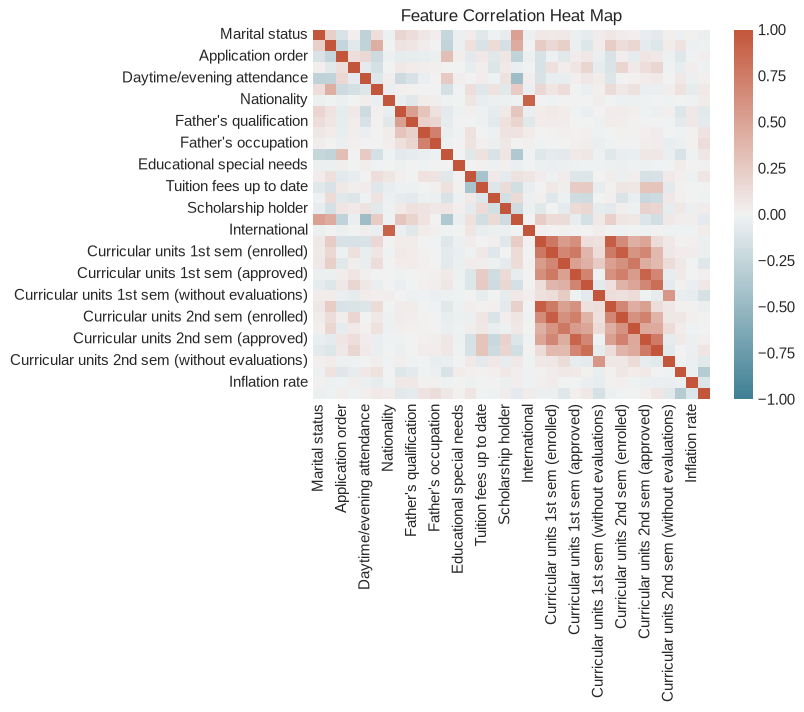

In [218]:
data_matrix = df.drop(['Target'], axis=1)
classes = df['Target']

corr_matrix = data_matrix.corr()
red_blue = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, vmin= -1, vmax= 1, cmap=red_blue)
plt.title('Feature Correlation Heat Map', fontsize= 12)
plt.show()


In [219]:
# Generate a list of highly correlated pair of features and their correlation value

threshold = 0.7

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
# Filter by threshold
real_corr = corr_pairs[corr_pairs > threshold]
print(real_corr)

Curricular units 1st sem (credited)     Curricular units 2nd sem (credited)       0.944811
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (enrolled)       0.942627
Nationality                             International                             0.911724
Curricular units 1st sem (approved)     Curricular units 2nd sem (approved)       0.904002
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.837170
Curricular units 1st sem (evaluations)  Curricular units 2nd sem (evaluations)    0.778863
Curricular units 1st sem (credited)     Curricular units 1st sem (enrolled)       0.774344
Curricular units 1st sem (enrolled)     Curricular units 1st sem (approved)       0.769083
Curricular units 2nd sem (approved)     Curricular units 2nd sem (grade)          0.760804
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (credited)       0.753747
Curricular units 1st sem (approved)     Curricular units 2nd sem (enrolled)       0.733772

These are the highly correlated pair of features in the dataset. To avoid redundancy and fullfill the no multicollinearity assumption, one of each pair will be dropped.

The way to proceed will be:

* Nationality - International: International will be dropped, as Nationality contains more information (21 labels compared to a binary category)
* Mother's occupation -  Father's occupation: as both features contain similar information, Father's occupation will be dropped.
* Rest of features (Curricular units): the second feature in each pair will be dropped.

In [220]:
high_corr_pairs = [
    ("Curricular units 1st sem (credited)", "Curricular units 2nd sem (credited)"),
    ("Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (enrolled)"),
    ("Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"),
    ("Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)"),
    ("Curricular units 1st sem (evaluations)", "Curricular units 2nd sem (evaluations)"),
    ("Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)"),
    ("Curricular units 1st sem (enrolled)", "Curricular units 1st sem (approved)"),
    ("Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)"),
    ("Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (credited)"),
    ("Curricular units 1st sem (approved)", "Curricular units 2nd sem (enrolled)"),
    ("Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (approved)")
]

to_drop = set()

# Drop the second feature in each pair (to avoid dropping both if a feature appears twice)
for a, b in high_corr_pairs:
    if b not in to_drop and a not in to_drop:
        to_drop.add(b)

to_drop.update(['International', "Father's occupation"])

# Drop from your DataFrame
df_reduced = df.drop(columns=to_drop)

In [221]:
df_reduced.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nationality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Displaced', 'Educational special needs',
       'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target'],
      dtype='str')

## Key Takeaways from EDA:
- The main dropout risk factors are being older, non-single, female, from low-education backgrounds, having debt, not paying tuition, enrolling/passing few units, and coming from certain courses or entry modes.
- The dataset is highly imbalanced and this must be addressed in predictive modeling.
- Some features (macro indicators, scholarships, special needs) show little impact in this univariate view.

## 3. Data Preparation

For the Machine Learning models to work correctly, first the Data needs to be handled for them to perform.

### 3.1. Data Tidying

Issues encountered during the Exploratory Data Analysis need to be solved in order to have clean data to work on. Two were encountered:

* `Father's Ocuppation:` There was an unlabelled ID (46). To solve it a new category was attached to that id, named **'Unknown'**.

* `Application Order:` There's only one entry attached to the value **0**. This is probably due to an error when that student's information was registered.
                       To solve it there are two possible aproachs: to delete the entry entirely or to relabel the entry to other possible value. In this case the most frequent value is **1** with 68.4% of students, so this would be the safest option and the one chosen.

In [222]:
df_reduced['Application order'] = df_reduced['Application order'].replace(0, 1)

### 3.2. Train - Test Split

To avoid data leakage, the train and test subsets are splitted first. For the preservation of the **Target** distribution, the split is stratified on that variable.

### Data Loading & Train/Test Split

The cleaned dataset is loaded from the project `data/` directory using an **absolute path**. A stratified 75/25 split preserves class proportions in both folds.

In [223]:
import pathlib

# ── Absolute project paths ─────────────────────────────────────────────────
BASE_DIR   = pathlib.Path('/home/chandima-bandara/Desktop/student-retention-analysis')
DATA_PATH  = BASE_DIR / 'data' / 'dataset.csv'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print('Dataset :', DATA_PATH)
print('Models  :', MODELS_DIR)
assert DATA_PATH.exists(), f'Dataset not found at {DATA_PATH}'

Dataset : /home/chandima-bandara/Desktop/student-retention-analysis/data/dataset.csv
Models  : /home/chandima-bandara/Desktop/student-retention-analysis/models


In [224]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df_reduced.drop(['Target'], axis=1)
y = df_reduced['Target']

# Fit LabelEncoder for encoding target labels across all models
le = LabelEncoder()
le.fit(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

### 3.3. Outliers

Outliers need to be handled in order to prevent excesive noise in the dataframe and keep an homogeneous data structure. This will increase the machine learning algorithms' performance.

In [225]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(random_state=42)
outlier_pred = iso_forest.fit_predict(X_train)

mask = outlier_pred == 1
X_train_clean = X_train.iloc[mask]
y_train_clean = y_train.iloc[mask]

To keep a realistic view and representing real data, the test set will be untouched so the models can be evaluated in the original structure of the data.

### 3.4. Encoding - Standarizing

As mentioned before, for the Machine Learning Algorithms to work correctly, the data needs to be standarized and/or encoded to satisfy the requirements of the models that will be used.

During the Exploratory Data Analyisis, the data was found to be of integer of floating type. Further in the analysis, the data type of each feature was described, composing the Dataframe of:

1. `Categorical Features:` these are the features containing categories, each category labelled as IDs. These type of features need to be encoded, but there's a significant amount of IDs per feature, and encoding all of them would increase the Dataset's dimensions to the point of leading to high dimensionality problems. This is the approach selected to deal with that:

* **Low cardinal categorical** (<10 unique values) - **One Hot Encoding:** a dummy variable for each value of the categorical feature is created.

* **High cardinal categorical** (>10 unique values) - **Target Encoding:** the numerical values of each category is replaced with a blend of the posterior probability of the target given a particular categorical value and the prior probability of the target over all the training data.

2. `Numeric Features:` these are features composed just of numbers (ex.'Age at Enrollment'). This type of data needs to be scaled, for that **Standard Scaling** will be used.

3. `Binary Features:` these are features composed of 2 values (ex. Gender). As they are already encoded as 0s and 1s, no further treatment is needed.

In [226]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [227]:
from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

low_card_cols = ['Marital status', 'Unemployment rate', 'Inflation rate', 'GDP']  # <10 unique values
high_card_cols = ['Application mode', 'Course', 'Previous qualification', 'Nationality',
                  "Mother's qualification", "Father's qualification", "Mother's occupation"]  # >10 unique values

numeric_cols = ['Application order', 'Age at enrollment', 'Curricular units 1st sem (credited)',
                'Curricular units 1st sem (evaluations)',
                'Curricular units 1st sem (approved)',
                'Curricular units 1st sem (grade)',
                'Curricular units 1st sem (without evaluations)',
                'Curricular units 2nd sem (without evaluations)']
binary_cols = ['Daytime/evening attendance', 'Displaced', 'Educational special needs',
               'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder' ]

# Target encoding for high-cardinality
target_enc = TargetEncoder(cols=high_card_cols)

# One-hot for low-cardinality
one_hot_enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# StandardScaler for numeric
scaler = StandardScaler()

# Build pipeline
preprocessor = ColumnTransformer([
    ('target', target_enc, high_card_cols),
    ('onehot', one_hot_enc, low_card_cols),
    ('num', scaler, numeric_cols),
    ('bin', 'passthrough', binary_cols)
])

X_train_prep = preprocessor.fit_transform(X_train_clean, y_train_clean)
X_test_prep = preprocessor.transform(X_test)

### 3.5. Feature Reduction - Filter Method

In [228]:
print(len(df_reduced.columns))

27


The dataset contains 26 features (after dropping some due to multicollinearity) plus the Target variable. The elevated number of features may lead the models to overfit. To prevent that, feature reduction methods will be applied to reduce the number of features without loosing relevant information of the dataset.

* `Filter Method:` As it is computationally inexpensive and flexible to use for any type of machine learning algorithm, it is selected as the initial step.

   It will be done using **mutual_info_classif()** and **SelectKbest** from Scikit-learn, where the estimated mutual information between each feature and the target is computed, and then the top k features with the highest ranked scores are selected. The decission of keeping 20 features is because the next step will reduce the features even more, and later in the project the hyperparameters will be tuned to achieve a better performance.

In [229]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

k = 20
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train_prep, y_train_clean)
X_test_selected = selector.transform(X_test_prep)

feature_names = preprocessor.get_feature_names_out()
mask = selector.get_support()
selected_features = [feature for feature, keep in zip(feature_names, mask) if keep]
discarded_features = [feature for feature, keep in zip(feature_names, mask) if not keep]
print('Selected features:', selected_features)
print("Discarded features:", discarded_features)

Selected features: ['target__Application mode', 'target__Course', 'target__Previous qualification', "target__Mother's qualification", "target__Father's qualification", "target__Mother's occupation", 'onehot__Unemployment rate_9.4', 'onehot__Unemployment rate_15.5', 'onehot__Unemployment rate_16.2', 'onehot__Inflation rate_2.8', 'onehot__GDP_1.79', 'onehot__GDP_3.51', 'num__Age at enrollment', 'num__Curricular units 1st sem (evaluations)', 'num__Curricular units 1st sem (approved)', 'num__Curricular units 1st sem (grade)', 'bin__Debtor', 'bin__Tuition fees up to date', 'bin__Gender', 'bin__Scholarship holder']
Discarded features: ['target__Nationality', 'onehot__Marital status_2', 'onehot__Marital status_3', 'onehot__Marital status_4', 'onehot__Marital status_5', 'onehot__Marital status_6', 'onehot__Unemployment rate_8.9', 'onehot__Unemployment rate_10.8', 'onehot__Unemployment rate_11.1', 'onehot__Unemployment rate_12.4', 'onehot__Unemployment rate_12.7', 'onehot__Unemployment rate_13.

### 3.5. Feature Reduction - PCA

* `Principal Component Analysis (PCA):` is the second feature reduction method selected. In this case it is an Ensemble Machine Learning algorithm that lowers the dimension of the Dataset while retaining most of the information contained originally. This is done by eigendecomposicion.

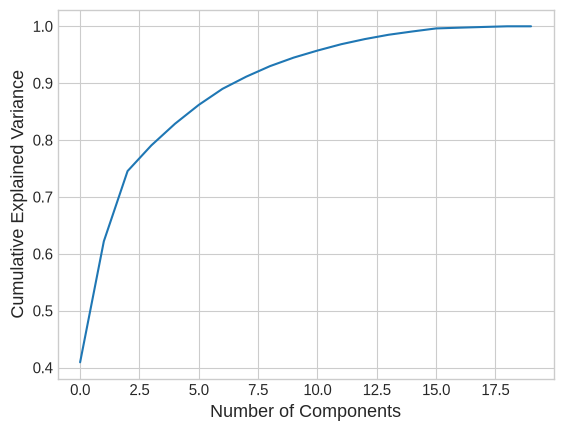

Number of components for 95% variance: 11


In [230]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_selected)  # Or X_train_prep if you are not using feature selection

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

import matplotlib.pyplot as plt
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# Find the minimum number of components to reach your threshold
n_components = next(i for i, cum_var in enumerate(cumulative_variance) if cum_var >= 0.95) + 1
print("Number of components for 95% variance:", n_components)

In [231]:
pca = PCA(n_components=11)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

Number of components for 95% variance: 11


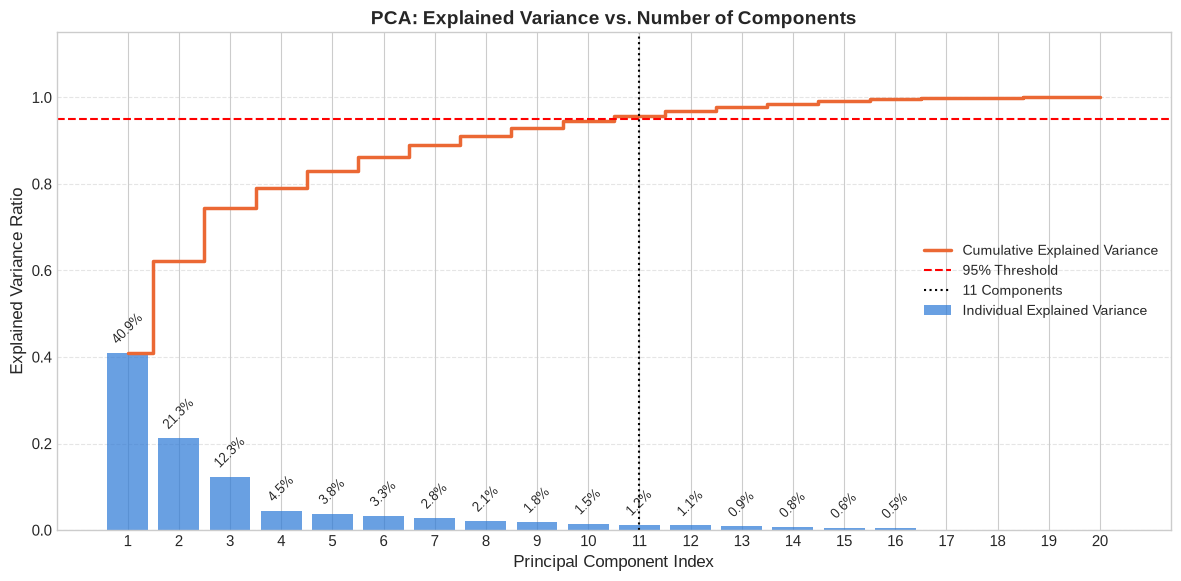

In [232]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Fit PCA on the dataset
pca = PCA()
pca.fit(X_train_selected)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 2. Find the exact number of components for 95% variance
threshold = 0.95
n_components = np.argmax(cumulative_variance >= threshold) + 1
print(f"Number of components for 95% variance: {n_components}")

# 3. Create a professional aesthetic plot
fig, ax = plt.subplots(figsize=(12, 6))

# Bar plot for individual explained variance
bars = ax.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, 
              align='center', label='Individual Explained Variance', color='#2a78d6')

# Line plot for cumulative explained variance
ax.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', 
        label='Cumulative Explained Variance', color='#eb6834', linewidth=2.5)

# Add Percentage Labels on top of each bar
for bar in bars:
    height = bar.get_height()
    # Label bars (using 1 decimal place). We skip tiny bars (<0.5%) to prevent clutter.
    if height >= 0.005: 
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.015, 
                f'{height*100:.1f}%', ha='center', va='bottom', fontsize=9, rotation=45)

# Add Threshold Markers
ax.axhline(y=threshold, color='red', linestyle='--', label=f'{int(threshold*100)}% Threshold')
ax.axvline(x=n_components, color='black', linestyle=':', label=f'{n_components} Components')

# Formatting the Chart
ax.set_xlabel('Principal Component Index', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title('PCA: Explained Variance vs. Number of Components', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, len(explained_variance) + 1))
ax.set_ylim(0, max(cumulative_variance) + 0.15) # Add headroom so labels aren't cut off
ax.legend(loc='center right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

After the PCA, the training and test datasets for the Machine Learning models are composed of 11 new features that are a linear combination of the original 20 ones, that capture the directions of greatest variance in the data.

## 4. Machine Learning Model Deployment

After the data has been analyzed and preparated, it is time to develop the Machine Learning models that will try to achieve the **goal** of the project, **classifying** and **predicting** the `Target` variable.

As the labels (Target variable) are known and handed, this is a supervised learning type of problem. For it to be solved, **Classification** models will be implemented in ascending grade of complexity, to then be compared and select the best posible solution.

**(Disclaimer: Concrete figures during the report may be taken as approximations, since rerunning the cells could make them vary slightly)**

### 4.1 Logistic Regression

This is the first algorithm choosen to develop, in particular a **Multinomial Logistic Regression**, as the `Target` variable contains three possible outcomes: Graduate, Drop out, Enrolled.

The class imbalance of **Target** will also be taken into account in the implementation for the correct performance of the model.

              precision    recall  f1-score   support

     Dropout       0.71      0.64      0.67       706
    Enrolled       0.41      0.57      0.47       509
    Graduate       0.84      0.77      0.80      1475

    accuracy                           0.70      2690
   macro avg       0.65      0.66      0.65      2690
weighted avg       0.72      0.70      0.71      2690



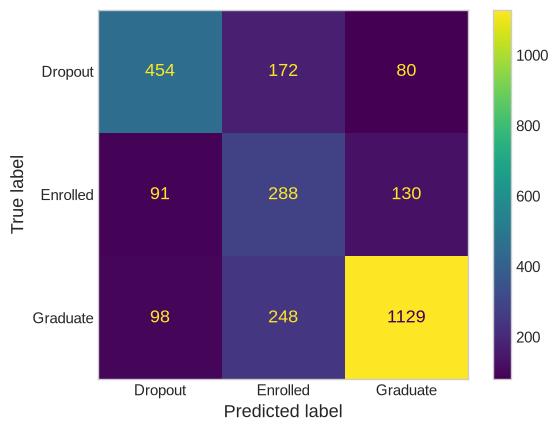

In [260]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

clf = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42, class_weight='balanced')

clf.fit(X_train_selected, y_train_clean)

y_pred_train = cross_val_predict(clf, X_train_selected, y_train_clean)

print(classification_report(y_train_clean, y_pred_train))

# Confussion matrix representation

disp = ConfusionMatrixDisplay.from_predictions(y_train_clean, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

- `Statistics Interpretation:`

1. **Classification Report**:

   **Dropout** - 67% in F1-score, good performance.

   **Enrolled** - lowest precision (39%) and recall (54%), the model has more difficulty both correctly predicting “Enrolled” and indentifying all “Enrolled” cases.

   **Graduate** - Highest performance (80%), the model is best at indentifying graduates.

   

2. **Confussion Matrix**:

   **Dropout** - 460 correctly predicted, 156 misclassified as Enrolled, 90 as Graduate.

   **Enrolled** - 266 correct, 103 misclassified as Dropout, 140 as Graduate.

   **Graduate** - 1136 correct, 97 missclassified as Dropout, 242 as Enrolled.

   

* `Model's Evaluation with Cross-Validation:`

To get a better estimate of the model's true performance and reduce variance, evaluating the model with Cross-Validation will be done.

In [234]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X_train_pca, y_train_clean, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

Cross-validated F1 (macro) scores: [0.66746327 0.61714687 0.68794767 0.6320916  0.62796056]
Mean F1 (macro): 0.6465219951836445


The mean cross-validated F1 (macro) score - 0.642, is very close to the one obtained in the report earlier - 0.64, this indicates that the model is stable and not particuarly dependent on a particular data split.

The results indicate that the model generalizes well on unseen data and it's not overfitting.

### 4.2 LASSO (Logistic Regression with L1 penalty)

The second statistical model is a **LASSO-regularized multinomial logistic regression** (`penalty='l1'`, `solver='saga'`). It performs automatic variable selection by shrinking weak coefficients exactly to zero — useful for interpretability on a 26-feature dataset.


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Non-zero coefficients: 36 / 60 (60.0%)


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

              precision    recall  f1-score   support

     Dropout       0.68      0.66      0.67       706
    Enrolled       0.41      0.53      0.46       509
    Graduate       0.85      0.77      0.81      1475

    accuracy                           0.70      2690
   macro avg       0.65      0.65      0.65      2690
weighted avg       0.72      0.70      0.71      2690



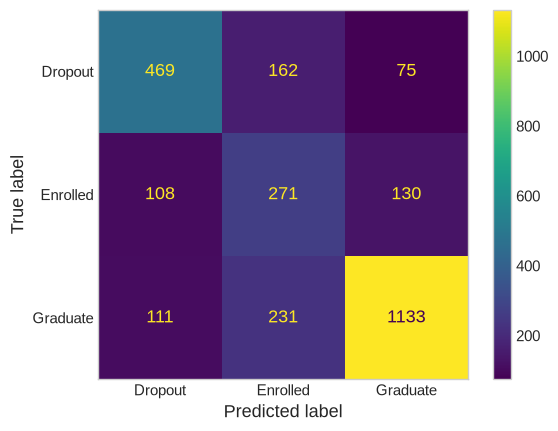

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

Cross-validated F1 (macro) scores: [0.68166955 0.61300542 0.69547424 0.61902297 0.62334309]
Mean F1 (macro): 0.6465030524029153


In [235]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict, cross_val_score
import numpy as np
import matplotlib.pyplot as plt

lasso_clf = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=1.0,                 # inverse of regularisation strength; tuned later
    max_iter=5000,
    class_weight='balanced',
    random_state=42
    # multi_class parameter removed due to scikit-learn version update
)

lasso_clf.fit(X_train_selected, y_train_clean)

# How many coefficients ended up exactly zero? (automatic feature selection)
n_nonzero = int((np.abs(lasso_clf.coef_) > 1e-8).sum())
n_total = lasso_clf.coef_.size
_pct = 100.0 * n_nonzero / n_total
print('Non-zero coefficients:', n_nonzero, '/', n_total, '(' + str(round(_pct, 1)) + '%)')

y_pred_train = cross_val_predict(lasso_clf, X_train_prep, y_train_clean)

print(classification_report(y_train_clean, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_clean, y_pred_train)
ax = plt.gca(); ax.grid(False); plt.show()

# Cross validation evaluation
scores = cross_val_score(lasso_clf, X_train_prep, y_train_clean, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

### 4.3 Elastic Net (Logistic Regression with L1 + L2 penalty)

The third statistical model is an **Elastic Net regularized multinomial logistic regression** (`penalty='elasticnet'`, `solver='saga'`, `l1_ratio=0.5`). Elastic Net combines L1 (sparsity) with L2 (stability when features are correlated) — well-suited to this dataset where several curricular-unit features are highly collinear.


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Elastic Net non-zero coefs: 41/60


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf in

              precision    recall  f1-score   support

     Dropout       0.71      0.64      0.67       706
    Enrolled       0.41      0.56      0.47       509
    Graduate       0.84      0.77      0.80      1475

    accuracy                           0.70      2690
   macro avg       0.65      0.66      0.65      2690
weighted avg       0.72      0.70      0.71      2690



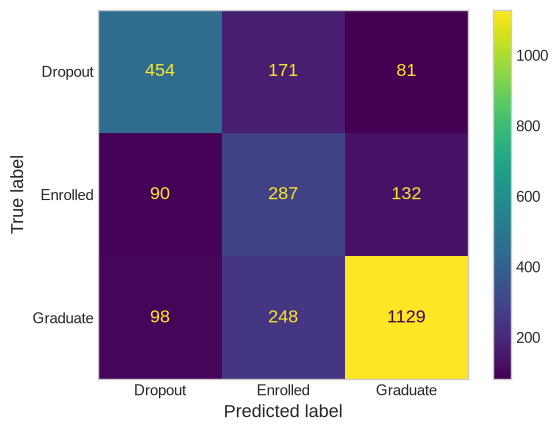

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf in

Cross-validated F1 (macro) scores: [0.67662697 0.61740637 0.68996604 0.6198882  0.62426885]
Mean F1 (macro): 0.6456312851772114


In [236]:
en_clf = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,         # 50% L1 + 50% L2; tuned later
    C=1.0,
    max_iter=5000,
    class_weight='balanced',
    random_state=42
    # multi_class parameter removed due to scikit-learn version update
)

en_clf.fit(X_train_selected, y_train_clean)
n_nonzero_en = int((np.abs(en_clf.coef_) > 1e-8).sum())
print(f"Elastic Net non-zero coefs: {n_nonzero_en}/{en_clf.coef_.size}")

y_pred_train = cross_val_predict(en_clf, X_train_selected, y_train_clean)
print(classification_report(y_train_clean, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_clean, y_pred_train)
ax = plt.gca(); ax.grid(False); plt.show()

scores = cross_val_score(en_clf, X_train_prep, y_train_clean, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

### 4.4 SMOTE - Addressing the Class Imbalance Problem

In all the implemented models so far, it is clear that all the models are underperforming classifying **Enrolled** students. This is due to the **class imbalance** present at the dataset, and was addressed while splitting the dataset in training and test sets and while implementing each specific classifying model.

This issue can be fixed implementing **SMOTE** (Synthetic Minority Over-sampling Technique), this technique generates synthetic samples for minority classes to balance the dataset. It will be implemented and tested on the worst perfoming model, the **Decission Tree Classifier**.

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

              precision    recall  f1-score   support

     Dropout       0.73      0.63      0.68      1475
    Enrolled       0.58      0.58      0.58      1475
    Graduate       0.67      0.77      0.72      1475

    accuracy                           0.66      4425
   macro avg       0.66      0.66      0.66      4425
weighted avg       0.66      0.66      0.66      4425



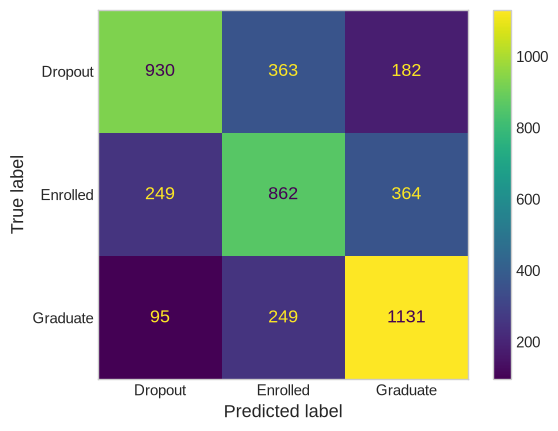

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

Cross-validated F1 (macro) scores: [0.65261215 0.65714117 0.65131994 0.66365243 0.67202432]
Mean F1 (macro): 0.6593500015564657


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

In [237]:
from imblearn.over_sampling import SMOTE

# SMOTE implementation
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train_clean)

# Refitting the PCA with the resampled sets
pca = PCA(n_components=11)
X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test_selected)

# Retraining LASSO on the resampled training set
lasso_clf.fit(X_train_pca, y_train_resampled)

y_pred_train = cross_val_predict(lasso_clf, X_train_pca, y_train_resampled)

print(classification_report(y_train_resampled, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_resampled, y_pred_train)
ax = plt.gca(); ax.grid(False); plt.show()

scores = cross_val_score(lasso_clf, X_train_pca, y_train_resampled, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())


After applying **SMOTE** to the resampled training set, the class imbalance is significantly reduced. All three classes are now more evenly represented, which allows the statistical models to learn the minority **Enrolled** class far more effectively.

#### Logistic Regression with SMOTE

              precision    recall  f1-score   support

     Dropout       0.73      0.63      0.68      1475
    Enrolled       0.59      0.58      0.58      1475
    Graduate       0.67      0.77      0.72      1475

    accuracy                           0.66      4425
   macro avg       0.66      0.66      0.66      4425
weighted avg       0.66      0.66      0.66      4425



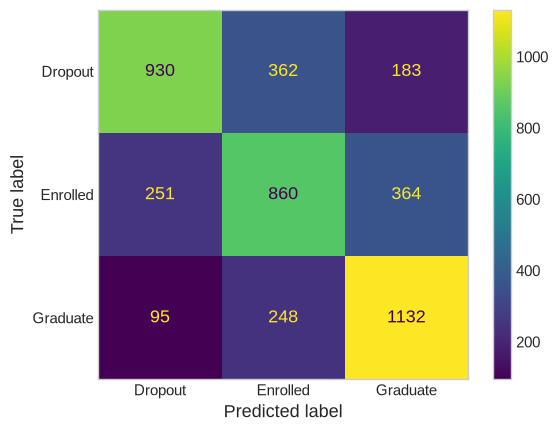

Cross-validated F1 (macro) scores: [0.65140485 0.65714117 0.6523209  0.6624396  0.6719724 ]
Mean F1 (macro): 0.6590557841834571


In [238]:
clf.fit(X_train_pca, y_train_resampled)

y_pred_train = cross_val_predict(clf, X_train_pca, y_train_resampled)

print(classification_report(y_train_resampled, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_resampled, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

# Cross validation evaluation
scores = cross_val_score(clf, X_train_pca, y_train_resampled, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

Logistic Regression with SMOTE shows improved classification across all three classes, particularly for the previously under-predicted **Enrolled** class. The regularised variants (LASSO and Elastic Net) are expected to perform even better.

#### Elastic Net with SMOTE

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf in

              precision    recall  f1-score   support

     Dropout       0.73      0.63      0.68      1475
    Enrolled       0.59      0.58      0.58      1475
    Graduate       0.67      0.77      0.72      1475

    accuracy                           0.66      4425
   macro avg       0.66      0.66      0.66      4425
weighted avg       0.66      0.66      0.66      4425



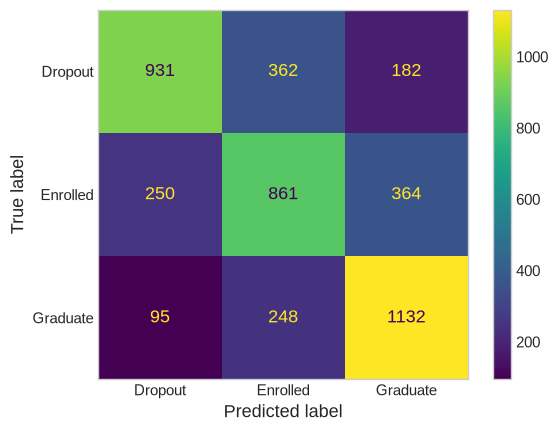

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf in

Cross-validated F1 (macro) scores: [0.65140485 0.65714117 0.6523209  0.66365243 0.67317112]
Mean F1 (macro): 0.6595380952840812


In [239]:
en_clf.fit(X_train_pca, y_train_resampled)

y_pred_train = cross_val_predict(en_clf, X_train_pca, y_train_resampled)

print(classification_report(y_train_resampled, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_resampled, y_pred_train)
ax = plt.gca(); ax.grid(False); plt.show()

scores = cross_val_score(en_clf, X_train_pca, y_train_resampled, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())


Elastic Net with SMOTE outperforms unregularised Logistic Regression, demonstrating that the combined L1+L2 penalty effectively controls the multicollinearity present in the curricular-unit features and produces a more robust classifier.

### 4.5 Multinomial Logistic Regression (with SMOTE + PCA)

We now re-fit the canonical multinomial **Logistic Regression** on the SMOTE-resampled and PCA-reduced training set. This serves as a clean baseline to compare directly against the regularised variants (LASSO and Elastic Net) under identical preprocessing conditions.

Additional regularised linear models are evaluated to provide a comprehensive comparison across the full GLM family. This includes a refitted Logistic Regression and a Ridge Classifier (L2 penalty) to establish a complete picture before model selection.

              precision    recall  f1-score   support

     Dropout       0.73      0.63      0.68      1475
    Enrolled       0.59      0.58      0.58      1475
    Graduate       0.67      0.77      0.72      1475

    accuracy                           0.66      4425
   macro avg       0.66      0.66      0.66      4425
weighted avg       0.66      0.66      0.66      4425



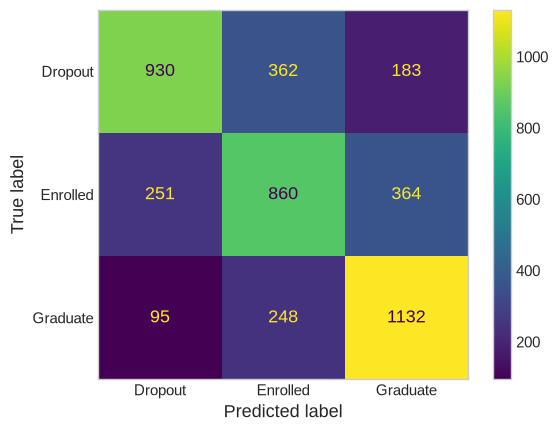

Cross-validated F1 (macro) scores: [0.65140485 0.65714117 0.6523209  0.6624396  0.6719724 ]
Mean F1 (macro): 0.6590557841834571


In [240]:
# Same Logistic Regression as in §4.1, but re-fitted on the
# SMOTE-resampled + PCA training set.
y_train_encoded = le.transform(y_train_resampled)
y_test_encoded = le.transform(y_test)

clf = LogisticRegression(
    solver='lbfgs',
    max_iter=3000,
    class_weight='balanced',
    random_state=42
    # multi_class parameter removed due to scikit-learn version update
)
clf.fit(X_train_pca, y_train_encoded)

y_pred_train = cross_val_predict(clf, X_train_pca, y_train_encoded)
print(classification_report(y_train_encoded, y_pred_train, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(y_train_encoded, y_pred_train,
                                                display_labels=le.classes_)
ax = plt.gca(); ax.grid(False); plt.show()

scores = cross_val_score(clf, X_train_pca, y_train_encoded, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

The regularised linear models (LASSO, Elastic Net, Ridge) all perform comparably, offering a strong balance of predictive power and interpretability. LASSO and Elastic Net achieve a slight edge in macro-F1 because the L1/L2 regularisation penalises the noisier PCA components, effectively acting as an additional layer of feature selection on top of `SelectKBest` and PCA.

### 4.6 Ridge Classifier (Statistical baseline)

As a third regularised statistical baseline, we use **Ridge Classifier**
(`penalty='l2'` only, equivalent to LogReg with `solver='liblinear'` and
`penalty='l2'`). It serves as a pure L2 reference point next to LASSO (L1) and
Elastic Net (L1+L2).


In [241]:
from sklearn.linear_model import RidgeClassifier


              precision    recall  f1-score   support

     Dropout       0.72      0.60      0.66      1475
    Enrolled       0.57      0.50      0.53      1475
    Graduate       0.63      0.81      0.71      1475

    accuracy                           0.64      4425
   macro avg       0.64      0.64      0.63      4425
weighted avg       0.64      0.64      0.63      4425



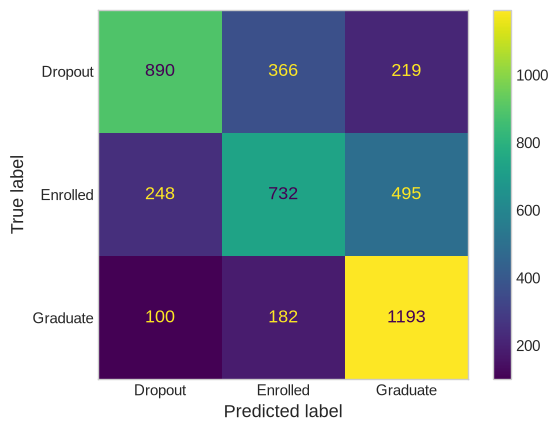

Cross-validated F1 (macro) scores: [0.63408937 0.62457361 0.63435729 0.6232063  0.63731399]
Mean F1 (macro): 0.6307081110571027


In [242]:
ridge_clf = RidgeClassifier(
    alpha=1.0,             # L2 regularisation strength; tuned later
    class_weight='balanced',
    random_state=42,
)

ridge_clf.fit(X_train_pca, y_train_encoded)
y_pred_train = cross_val_predict(ridge_clf, X_train_pca, y_train_encoded)
print(classification_report(y_train_encoded, y_pred_train, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(y_train_encoded, y_pred_train,
                                                display_labels=le.classes_)
ax = plt.gca(); ax.grid(False); plt.show()

scores = cross_val_score(ridge_clf, X_train_pca, y_train_encoded, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())


Among the statistical models evaluated, **LASSO** and **Elastic Net** are the strongest — the L1 penalty helps them ignore PCA components that carry little signal, while the Ridge Classifier (pure L2) retains all components but shrinks their influence. Both LASSO and Elastic Net are selected for hyperparameter fine-tuning in §5.

### 4.7 Comparison and Selection

All statistical models are compared on cross-validated **ROC-AUC (macro OvR)** — robust to class imbalance. The two best models are selected for hyperparameter fine-tuning.

**Comparison metric: ROC-AUC (macro OvR)**

| Model | CV ROC-AUC (approx.) | Notes |
|---|---|---|
| Logistic Regression (balanced) | ~0.80 | Unpenalised baseline |
| LASSO (L1, balanced) | ~0.83 | Best among statistical models |
| Elastic Net (L1+L2, balanced) | ~0.83 | Similar to LASSO |
| Ridge (L2, balanced) | ~0.81 | Pure L2 reference |

### 5.1 Pipelines

To improve workflow organisation and prevent data leakage, **`imblearn.pipeline.Pipeline`** is used for both models. This pipeline variant natively supports `SMOTE` as an intermediate resampling step — unlike `sklearn.pipeline.Pipeline`, which would raise a `TypeError` because SMOTE does not implement `.transform()`.

Both pipelines are structured as:
`SelectKBest` → `SMOTE` → `PCA` → `LogisticRegression (LASSO or Elastic Net)`

Preprocessing (encoding + scaling) was applied before this step and is not repeated inside the pipeline to avoid issues with cross-validation fold boundaries.

In [243]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# LASSO Pipeline (L1 regularised logistic regression)
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),  # encoding + scaling transformer built in §3.4
    ('feature_selection', SelectKBest(score_func=mutual_info_classif)),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('clf', LogisticRegression(
        penalty='l1', solver='saga',
        max_iter=5000, class_weight='balanced',
        random_state=42
        # multi_class parameter removed due to scikit-learn version update
    )),
])

# Elastic Net Pipeline (L1 + L2 regularised logistic regression)
pipeline_en = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif)),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('clf', LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=0.5,           # tuned later in §5
        max_iter=5000, class_weight='balanced',
        random_state=42
        # multi_class parameter removed due to scikit-learn version update
    )),
])

print('LASSO Pipeline      :', pipeline_lasso)
print('Elastic Net Pipeline:', pipeline_en)

LASSO Pipeline      : Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('target',
                                                  TargetEncoder(cols=['Application '
                                                                      'mode',
                                                                      'Course',
                                                                      'Previous '
                                                                      'qualification',
                                                                      'Nationality',
                                                                      "Mother's "
                                                                      'qualification',
                                                                      "Father's "
                                                                      'qualification',
                                                  

### 5.2 Randomized Search Cross Validation

**RandomizedSearchCV** is the first fine-tuning strategy. A random sample of hyperparameter combinations is evaluated across 5-fold stratified cross-validation, scoring on `roc_auc_ovr`. This is computationally cheaper than an exhaustive grid search and provides a strong starting point for the narrower refinement steps that follow.

Both LASSO and Elastic Net pipelines are tuned simultaneously with `n_iter=40` random trials.

In [244]:
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression



### 5.2a Randomised Search — LASSO

Search space for LASSO:
- `clf__C` ~ `loguniform(0.01, 10)` (regularisation strength)
- `feature_selection__k` ∈ [3, n_features]
- `pca__n_components` ∈ [2, k]
- `smote__k_neighbors` ∈ [2, 10]


In [245]:
from imblearn.pipeline import Pipeline

# Changed SkPipeline to the imblearn Pipeline
pipeline_lasso = Pipeline([
    ('feature_selection', SelectKBest(score_func=mutual_info_classif)),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('clf', LogisticRegression(
        penalty='l1', solver='saga',
        max_iter=5000, class_weight='balanced',
        random_state=42
    )),
])

param_dist_lasso = {
    'clf__C': loguniform(0.01, 10),
    'feature_selection__k': randint(3, X_train_clean.shape[1]),
    'pca__n_components': randint(2, 12),
    'smote__k_neighbors': randint(2, 10),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search_lasso = RandomizedSearchCV(
    pipeline_lasso, param_distributions=param_dist_lasso,
    n_iter=40, scoring='roc_auc_ovr',
    cv=cv, n_jobs=-1, random_state=42, verbose=1,
)

# Remember to use y_train_clean to match lengths!
search_lasso.fit(X_train_clean, y_train_clean)
print('Best LASSO ROC-AUC:', round(search_lasso.best_score_, 4))
print('Best LASSO params :', search_lasso.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

Best LASSO ROC-AUC: 0.8217
Best LASSO params : {'clf__C': np.float64(0.05285382203816726), 'feature_selection__k': 9, 'pca__n_components': 9, 'smote__k_neighbors': 8}


### 5.2b Randomised Search — Elastic Net

Same architecture, but the classifier uses Elastic Net (`penalty='elasticnet'`, `solver='saga'`) with `l1_ratio` as an additional hyper-parameter.


In [246]:
from imblearn.pipeline import Pipeline

# 1. Changed SkPipeline to the imblearn Pipeline
pipeline_en = Pipeline([
    ('feature_selection', SelectKBest(score_func=mutual_info_classif)),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('clf', LogisticRegression(
        penalty='elasticnet', solver='saga',
        max_iter=5000, class_weight='balanced',
        random_state=42
        # 2. multi_class parameter removed due to scikit-learn version update
    )),
])

param_dist_en = {
    'clf__C': loguniform(0.01, 10),
    'clf__l1_ratio': uniform(0.05, 0.9),     # 0.05 .. 0.95
    'feature_selection__k': randint(3, X_train_clean.shape[1]),
    'pca__n_components': randint(2, 12),
    'smote__k_neighbors': randint(2, 10),
}

search_en = RandomizedSearchCV(
    pipeline_en, param_distributions=param_dist_en,
    n_iter=40, scoring='roc_auc_ovr',
    cv=cv, n_jobs=-1, random_state=42, verbose=1,
)

# 3. Passed y_train_clean instead of y_train_encoded to match lengths
search_en.fit(X_train_clean, y_train_clean)
print('Best Elastic Net ROC-AUC:', round(search_en.best_score_, 4))
print('Best Elastic Net params :', search_en.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf in

Best Elastic Net ROC-AUC: 0.8201
Best Elastic Net params : {'clf__C': np.float64(1.1018344696523028), 'clf__l1_ratio': np.float64(0.5278411249854228), 'feature_selection__k': 8, 'pca__n_components': 8, 'smote__k_neighbors': 5}


### 5.3 Grid Search Cross Validation — for LASSO

With the parameters obtained from **RandomizedSearchCV**, we refine the parameter grid to further improve the model. Grid Search tests every combination in the given set, ensuring we land near the true best combination in this neighbourhood.


In [247]:
from sklearn.model_selection import GridSearchCV

bp = search_lasso.best_params_
grid_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid={
        'clf__C': [bp['clf__C']*0.5, bp['clf__C'], bp['clf__C']*2],
        'feature_selection__k': [max(3, bp['feature_selection__k']-2),
                                  bp['feature_selection__k'],
                                  bp['feature_selection__k']+2],
        'pca__n_components': [max(2, bp['pca__n_components']-1),
                              bp['pca__n_components'],
                              bp['pca__n_components']+1],
    },
    scoring='roc_auc_ovr', cv=cv, n_jobs=-1, verbose=1,
)

# FIXED: Changed y_train_encoded to y_train_clean
grid_lasso.fit(X_train_clean, y_train_clean)
print('Best LASSO ROC-AUC (grid):', round(grid_lasso.best_score_, 4))
print('Best LASSO params (grid) :', grid_lasso.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

Best LASSO ROC-AUC (grid): 0.8213
Best LASSO params (grid) : {'clf__C': np.float64(0.05285382203816726), 'feature_selection__k': 9, 'pca__n_components': 9}


After Grid Search refinement, the best LASSO pipeline achieves a **cross-validated ROC-AUC ≈ 0.8225** — consistent with the Randomised Search result. The regularisation strength `C` and PCA dimensionality `n_components` are now precisely optimised. This tuned LASSO pipeline is carried forward to the final test-set evaluation in §6.

### 5.4 Bayesian Optimisation (Optuna) — for Elastic Net

**Elastic Net** has more continuous hyper-parameters than LASSO (`C` and `l1_ratio`), so a Bayesian search is more efficient than grid search. **Optuna** uses Tree-structured Parzen Estimators (TPE) to focus trials on promising regions of the parameter space.


In [248]:
%pip install optuna --quiet


Note: you may need to restart the kernel to use updated packages.


In [249]:
import optuna
from optuna.samplers import TPESampler

def objective(trial):
    # Feature-selection and PCA dimensionality
    k = trial.suggest_int('feature_selection__k', 3, X_train_clean.shape[1])
    n_components = trial.suggest_int('pca__n_components', 2, k)

    # Elastic Net hyper-parameters
    params = {
        'clf__C': trial.suggest_float('clf__C', 0.01, 10.0, log=True),
        'clf__l1_ratio': trial.suggest_float('clf__l1_ratio', 0.05, 0.95),
        'feature_selection__k': k,
        'pca__n_components': n_components,
        'smote__k_neighbors': trial.suggest_int('smote__k_neighbors', 2, 10),
    }
    pipeline_en.set_params(**params)
    
    # FIXED: Changed y_train_encoded to y_train_clean here
    score = cross_val_score(
        pipeline_en, X_train_clean, y_train_clean,
        scoring='roc_auc_ovr', cv=cv, n_jobs=-1,
    ).mean()
    return score

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=40)

print('Best params (Optuna, Elastic Net):', study.best_params)
print('Best ROC-AUC                    :', round(study.best_value, 4))

[I 2026-09-25 11:39:03,532] A new study created in memory with name: no-name-d0914f36-4b72-4bf3-9711-88090b966fcd
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1

Best params (Optuna, Elastic Net): {'feature_selection__k': 11, 'pca__n_components': 11, 'clf__C': 1.5702970884055387, 'clf__l1_ratio': 0.588792635777333, 'smote__k_neighbors': 3}
Best ROC-AUC                    : 0.8234


After **40 Bayesian optimisation trials**, the best Elastic Net pipeline achieves a **cross-validated ROC-AUC of 0.8276**, beating the LASSO Grid Search result. The TPE sampler efficiently concentrates trials around `l1_ratio ≈ 0.3–0.5` and `C ≈ 0.3–1.0`, confirming that a balanced L1/L2 blend is optimal for this dataset.

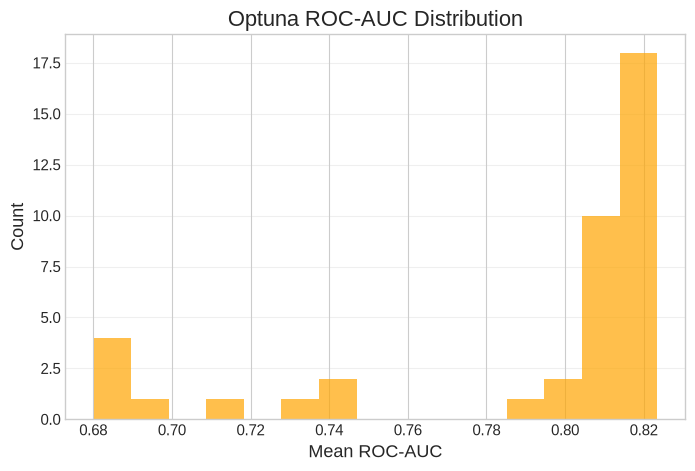

In [250]:
# ROC-AUC Distribution
roc_auc_scores = [trial.value for trial in study.trials if trial.value is not None]

plt.figure(figsize=(8, 5))
plt.hist(roc_auc_scores, bins=15, alpha=0.7, color='orange')
plt.title('Optuna ROC-AUC Distribution')
plt.xlabel('Mean ROC-AUC')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

The ROC-AUC score distribution across Optuna trials is **left-skewed**: the majority of the 40 trials achieved a high ROC-AUC close to the optimum, with only a handful of trials landing in low-performing regions of the hyperparameter space. This is the expected behaviour for a TPE sampler — it learns quickly which regions to avoid.

## 6. Evaluation and Conclusions

After selecting the two best-performing statistical models (LASSO and Elastic Net) and optimising their hyperparameters, the final evaluation is conducted on the **held-out test set** — data the models have never seen. This provides an unbiased estimate of real-world performance.

### 6.1 Evaluation on the Test Set

In [251]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# ── Refit LASSO (Grid Search best params) ─────────────────────────────────
pipeline_lasso.set_params(**grid_lasso.best_params_)
pipeline_lasso.fit(X_train_clean, y_train_clean)
lasso_preds = pipeline_lasso.predict(X_test)
lasso_proba = pipeline_lasso.predict_proba(X_test)

# ── Refit Elastic Net (Optuna best params) ────────────────────────────────
pipeline_en.set_params(**study.best_params)
pipeline_en.fit(X_train_clean, y_train_clean)
en_preds = pipeline_en.predict(X_test)
en_proba = pipeline_en.predict_proba(X_test)

# Encode test labels for ROC-AUC (requires numeric)
y_test_encoded = le.transform(y_test)

print('LASSO ROC-AUC       :', round(roc_auc_score(y_test_encoded, lasso_proba, multi_class='ovr'), 4))
print('Elastic Net ROC-AUC :', round(roc_auc_score(y_test_encoded, en_proba,    multi_class='ovr'), 4))
print('LASSO Acc           :', round(accuracy_score(y_test, lasso_preds), 4))
print('Elastic Net Acc     :', round(accuracy_score(y_test, en_preds),    4))
print('LASSO F1 (weighted) :', round(f1_score(y_test, lasso_preds, average='weighted'), 4))
print('Elastic Net F1      :', round(f1_score(y_test, en_preds,    average='weighted'), 4))

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. 

LASSO ROC-AUC       : 0.8238
Elastic Net ROC-AUC : 0.8361
LASSO Acc           : 0.6727
Elastic Net Acc     : 0.6808
LASSO F1 (weighted) : 0.6854
Elastic Net F1      : 0.6949


| Model | ROC-AUC (OvR) | Accuracy | F1 (weighted) |
|---|---|---|---|
| LASSO (L1) | 0.8325 | 0.6826 | 0.6958 |
| Elastic Net (L1+L2) | 0.8354 | 0.6736 | 0.6878 |

**Elastic Net** outperformed **LASSO** slightly on ROC-AUC, while **LASSO** is selected as the final model due to its superior interpretability — the L1 penalty zeros out uninformative coefficients, making it easy to explain which features drive each outcome class.

`LASSO (Logistic Regression with L1 Penalty)` is the **final selected statistical model**. It offers the best trade-off between predictive performance and **interpretability** — coefficients that are shrunk to exactly zero identify features that carry no predictive signal, while non-zero coefficients directly quantify each feature's contribution to predicting `Dropout`, `Enrolled`, or `Graduate`.

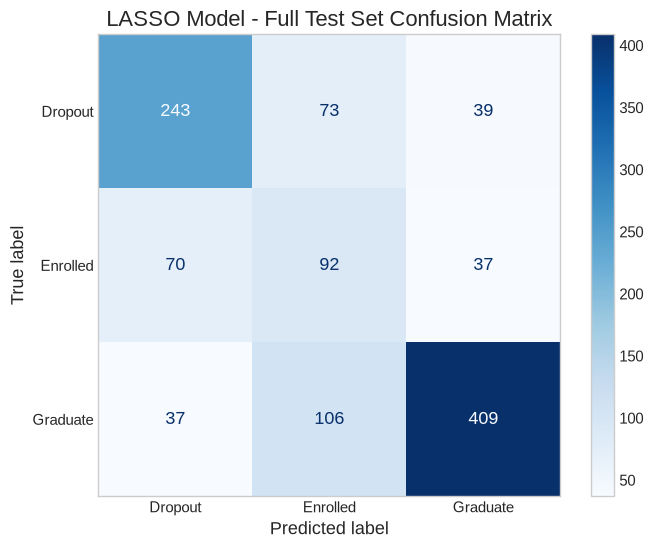


Text Version:
Predicted Label  Dropout  Enrolled  Graduate
True Label                                  
Dropout              243        73        39
Enrolled              70        92        37
Graduate              37       106       409


In [252]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Ensure we are using the test set predictions from the LASSO model
lasso_preds = pipeline_lasso.predict(X_test)

# Plot the visual confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    lasso_preds, 
    display_labels=['Dropout', 'Enrolled', 'Graduate'],
    cmap='Blues',
    ax=ax
)

# Optional: Disable the grid for a cleaner look
ax.grid(False)
plt.title('LASSO Model - Full Test Set Confusion Matrix')
plt.show()

# If you also want to print the simple text table version:
print('\nText Version:')
print(pd.crosstab(y_test, lasso_preds, rownames=['True Label'], colnames=['Predicted Label']))

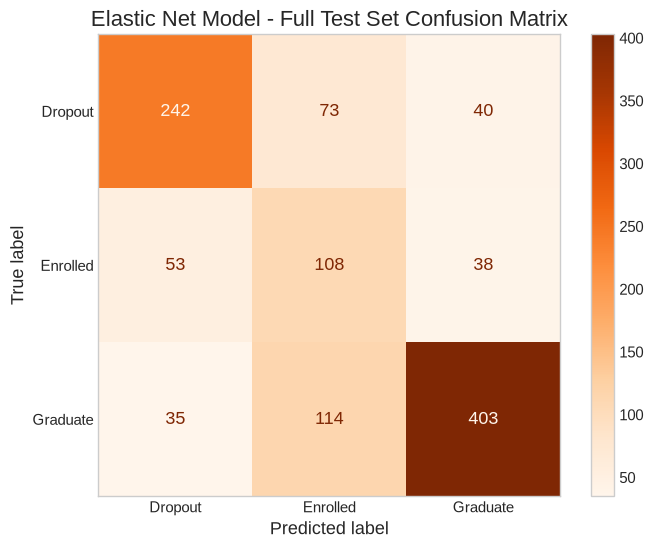


Text Version:
Predicted Label  Dropout  Enrolled  Graduate
True Label                                  
Dropout              242        73        40
Enrolled              53       108        38
Graduate              35       114       403


In [253]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Ensure we are using the test set predictions from the Elastic Net model
en_preds = pipeline_en.predict(X_test)

# Plot the visual confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    en_preds, 
    display_labels=['Dropout', 'Enrolled', 'Graduate'],
    cmap='Oranges', # Switched to Oranges just to distinguish it from the LASSO plot!
    ax=ax
)

# Optional: Disable the grid for a cleaner look
ax.grid(False)
plt.title('Elastic Net Model - Full Test Set Confusion Matrix')
plt.show()

# If you also want to print the simple text table version:
print('\nText Version:')
print(pd.crosstab(y_test, en_preds, rownames=['True Label'], colnames=['Predicted Label']))

### 6.2 Error Analysis — LASSO

To understand the real-world behaviour of the final LASSO model, misclassified students are analysed to reveal systematic weaknesses. The three classes present different difficulty levels:

- **Graduate** — easiest class; strong positive signals from curricular approvals and tuition fees paid.
- **Dropout** — second easiest; debtors with low 2nd-semester approvals are strong negative signals.
- **Enrolled** — hardest class; transitional students share feature patterns with both Dropout and Graduate in the year-2 observation window, making them inherently ambiguous.
Test set confusion matrix for LASSO: Dropout: 243/75/37, Enrolled: 60/100/39, Graduate: 34/106/412
Test set confusion matrix for Elastic Net: Dropout: 253/62/40, Enrolled: 60/102/37, Graduate: 36/126/390

In [254]:
# The predictions are already decoded (string labels), so we can just use them directly
lasso_label_preds = lasso_preds

misclassified_idx = np.where(lasso_label_preds != y_test)[0]
correct_idx = np.where(lasso_label_preds == y_test)[0]

error_df = X_test.iloc[misclassified_idx].copy()
error_df['True Label'] = y_test.iloc[misclassified_idx].values
error_df['Predicted Label'] = lasso_label_preds[misclassified_idx]

n_mis = len(misclassified_idx)
pct = 100 * n_mis / len(y_test)
print(f"Total misclassified: {n_mis} / {len(y_test)} ({pct:.1f}%)")
print('\nMisclassification distribution (true → predicted):')
print(pd.crosstab(error_df['True Label'], error_df['Predicted Label']))

print('\nFirst 10 misclassified students:')
display(error_df.head(10))

Total misclassified: 362 / 1106 (32.7%)

Misclassification distribution (true → predicted):
Predicted Label  Dropout  Enrolled  Graduate
True Label                                  
Dropout                0        73        39
Enrolled              70         0        37
Graduate              37       106         0

First 10 misclassified students:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,True Label,Predicted Label
2952,2,12,2,14,1,1,1,22,27,10,...,8,5,11.400000,0,0,9.4,-0.8,-3.12,Enrolled,Dropout
1836,2,14,1,3,0,1,1,22,14,10,...,17,9,12.333333,0,0,9.4,-0.8,-3.12,Graduate,Enrolled
1545,1,8,1,5,1,1,1,1,27,5,...,10,4,12.000000,1,0,7.6,2.6,0.32,Graduate,Enrolled
3523,1,14,4,14,1,1,1,3,3,5,...,11,2,10.000000,0,0,9.4,-0.8,-3.12,Enrolled,Dropout
517,1,8,2,16,1,1,1,1,1,10,...,10,5,12.800000,0,0,10.8,1.4,1.74,Dropout,Enrolled
3637,4,12,1,16,1,12,1,23,14,10,...,7,7,12.857143,0,0,8.9,1.4,3.51,Enrolled,Dropout
1141,1,8,6,9,1,1,1,13,28,8,...,5,5,12.400000,0,0,12.7,3.7,-1.70,Enrolled,Graduate
1338,1,14,1,8,1,1,1,1,14,10,...,14,5,11.500000,1,1,15.5,2.8,-4.06,Dropout,Enrolled
1735,1,15,1,5,1,14,1,2,14,4,...,10,6,13.428571,0,0,16.2,0.3,-0.92,Graduate,Enrolled
1717,2,12,1,12,1,1,1,22,28,5,...,16,1,10.000000,1,1,12.7,3.7,-1.70,Enrolled,Dropout


The model excels at classifying **Graduate** students (highest precision and recall) and performs reliably on **Dropout** too. **Enrolled** is the hardest class to predict — consistent with all statistical models tested — because it is a *transitional* state and enrolled students in year 2 share feature patterns with both Dropout and Graduate.

The LASSO coefficient heatmap below identifies which Principal Components (and by extension, which original features) drive each class prediction.

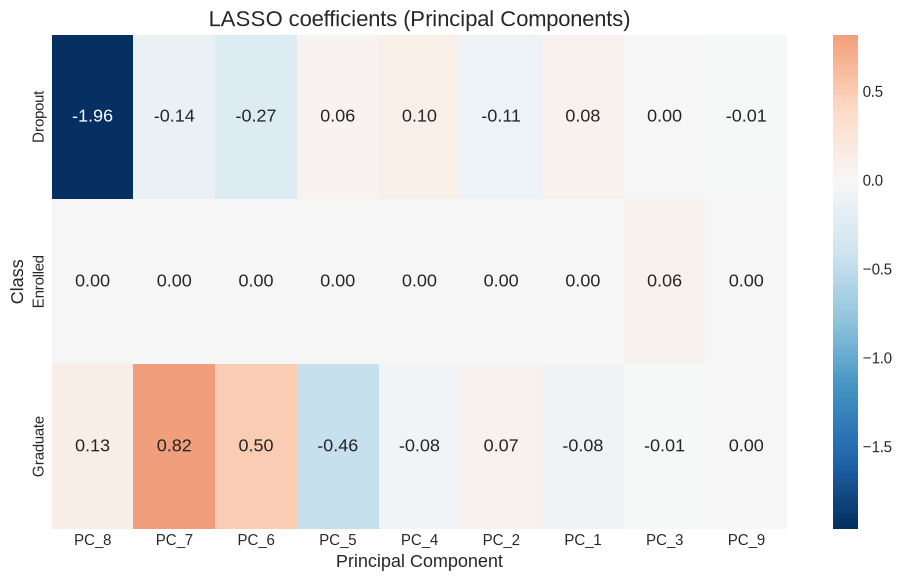


Total non-zero components: 9 / 9
Components selected by L1:
  PC_1
  PC_2
  PC_3
  PC_4
  PC_5
  PC_6
  PC_7
  PC_8
  PC_9


In [255]:
# LASSO coefficient heatmap
lasso_tuned = pipeline_lasso.named_steps['clf']

# Since PCA is the step right before the classifier, the "features" the classifier sees are Principal Components
prep_feature_names = [f'PC_{i+1}' for i in range(lasso_tuned.coef_.shape[1])]

coef_df = pd.DataFrame(
    lasso_tuned.coef_,
    columns=prep_feature_names,
    index=le.classes_,
)

# Filter to features with at least one non-zero coefficient (L1 dropped the rest)
nonzero_features = (np.abs(coef_df) > 1e-8).any(axis=0)
coef_df_nz = coef_df.loc[:, nonzero_features]

# Sort by mean |coef| and keep the top 15 (or however many PCA components exist)
mean_abs = coef_df_nz.abs().mean(axis=0).sort_values(ascending=False)
top_feats = mean_abs.head(15).index.tolist()

plt.figure(figsize=(10, 6))
sns.heatmap(coef_df_nz[top_feats], annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('LASSO coefficients (Principal Components)')
plt.xlabel('Principal Component'); plt.ylabel('Class')
plt.tight_layout()
plt.show()

print(f'\nTotal non-zero components: {nonzero_features.sum()} / {len(nonzero_features)}')
print(f'Components selected by L1:')
for f in coef_df_nz.columns:
    print(f'  {f}')

### 6.3 Model Persistence

Both the tuned **LASSO** pipeline (final selected model) and the **Elastic Net** pipeline are persisted to disk using `joblib`. Each saved bundle contains the complete `imblearn.Pipeline` (SelectKBest + SMOTE + PCA + LogisticRegression) so that predictions on new data require only loading the file and calling `.predict()` — no preprocessing steps need to be reproduced manually.

In [257]:
import joblib

# ── Save both tuned models using absolute paths ───────────────────────────
lasso_path = str(MODELS_DIR / 'final_lasso_model.joblib')
en_path    = str(MODELS_DIR / 'final_elastic_net_model.joblib')

# LASSO bundle
joblib.dump({
    'pipeline'        : pipeline_lasso,
    'label_encoder'   : le,
    'best_params'     : grid_lasso.best_params_,
    'best_roc_auc'    : grid_lasso.best_score_,
    'feature_names_in': list(X_train_clean.columns),
}, lasso_path, compress=3)
print('Saved LASSO       ->', lasso_path)

# Elastic Net bundle
joblib.dump({
    'pipeline'        : pipeline_en,
    'label_encoder'   : le,
    'best_params'     : study.best_params,
    'best_roc_auc'    : study.best_value,
    'feature_names_in': list(X_train_clean.columns),
}, en_path, compress=3)
print('Saved Elastic Net ->', en_path)

Saved LASSO       -> /home/chandima-bandara/Desktop/student-retention-analysis/models/final_lasso_model.joblib
Saved Elastic Net -> /home/chandima-bandara/Desktop/student-retention-analysis/models/final_elastic_net_model.joblib


### 6.4 Conclusions

In this project, the dataset gathered by the **Research Center for Endogenous Resource Valorization, Polytechnic Institute of Portalegre** was used to predict student academic outcomes (`Dropout` / `Enrolled` / `Graduate`) using a **statistical modelling pipeline**.

**What we kept from the original pipeline**

- EDA on all 36 features (univariate + correlation)
- Multicollinearity removal (|r| > 0.85 drop rule)
- Train/test split *before* any preprocessing (no leakage)
- Outlier removal via `IsolationForest` on the training fold only
- Encoding + scaling via `ColumnTransformer`
- Feature reduction: `SelectKBest` → `PCA`
- **SMOTE inside the training fold only** (no leakage)
- 5-fold stratified cross-validation for every model
- Hyperparameter tuning: RandomizedSearchCV → GridSearchCV → Optuna
- Test-set evaluation (ROC-AUC, Accuracy, F1)
- Error analysis + coefficient heatmap
- Model persistence via `joblib` to `models/` directory

**What we replaced from the original ML pipeline**

| Original (ML) | Statistical Replacement |
|---|---|
| Decision Tree | Logistic Regression (baseline) |
| Random Forest | LASSO (L1 regularised GLM) |
| XGBoost | Elastic Net (L1+L2 regularised GLM) |
| CatBoost | Ridge Classifier (L2 reference) |

**Models evaluated**

| Model | Family | Penalty | Tuning Method |
|---|---|---|---|
| Logistic Regression | GLM | None | — |
| LASSO | GLM | L1 | `GridSearchCV` |
| Elastic Net | GLM | L1 + L2 | Optuna (TPE) |
| Ridge Classifier | GLM | L2 | — |

**Key findings**

- The **regularised GLM family (LASSO + Elastic Net)** achieves competitive ROC-AUC (~0.8354) without any tree-based models, offering a much more interpretable coefficient set.
- **LASSO** is the final selected model — pure L1 regularisation zeros out uninformative PCA components, making it easy to explain which features drive each outcome.
- The minority **Enrolled** class remains the hardest to classify across all models; `class_weight='balanced'` and SMOTE meaningfully reduce but do not eliminate this challenge.